# Part A — Big Data Analytics on DDoS Network Traffic

**Student:** Benjamine (Batch 18, MSc Artificial Intelligence, University of Moratuwa)  
**Module:** Big Data Analytics Mini Project  
**Environment:** Google Colab + Apache Spark (PySpark)  
**Dataset:** BCCC-cPacket-Cloud-DDoS-2024 — York University / cPacket Networks (Kaggle, CC-BY-SA-4.0)

---

## Dataset Rationale

The BCCC-cPacket-Cloud-DDoS-2024 dataset was published in March 2024, making it one of the most recent publicly available DDoS datasets. The research paper behind it explicitly addresses 15 shortcomings found in older benchmark datasets such as CICIDS2017, including unrealistic traffic mixing and missing cloud-native attack patterns. The dataset contains **540,494 network flow records** with **319 features** per flow, covering 26 distinct traffic scenarios including 16 specific DDoS attack types.

This scale justifies the use of Apache Spark. Processing 319 features across half a million rows using pandas would load the entire dataset into a single machine's memory and would not demonstrate the distributed computing principles this course addresses. Using PySpark, the computation is parallelised across partitions and only small aggregated results are collected back to the driver.

---

## Analytical Questions

The analysis is structured around five questions that build on each other:

1. **Distribution** — What is the breakdown of specific attack types? Which are dominant and which are rare?
2. **Feature Signatures** — What are the measurable traffic characteristics of each attack type?
3. **Timing Patterns** — How do packet inter-arrival times and flow durations differ across attack categories?
4. **Flag Signatures** — Which TCP flag combinations are characteristic of each attack type?
5. **Discrimination** — Which features most clearly separate attack from benign traffic?

The top discriminating features from Question 5 become the content vectors for Part B, creating a direct analytical bridge between the EDA here and the recommendation system.

---

## Notebook Structure

| Section | Content |
|---|---|
| 0 | Setup — libraries, Spark session |
| 1 | Data loading — Kaggle API, Parquet read, sample inspection |
| 2 | Label structure — understanding `label` vs `activity` |
| 3 | Data cleaning and preprocessing |
| 4 | EDA Q1 — Attack type distribution |
| 5 | EDA Q2 — Traffic feature signatures + centroid export |
| 6 | EDA Q3 — Flow timing patterns + intensity ranking |
| 7 | EDA Q4 — TCP flag heatmap |
| 8 | EDA Q5 — Feature discrimination analysis |
| 9 | Summary and Part B handoff |

---
## Section 0 — Environment Setup

Google Colab serves as the execution environment. PySpark requires installation in each new session since it is not pre-installed. The `matplotlib` and `pandas` imports are used only for visualisation after Spark has completed the heavy aggregation — the full 540k-row DataFrame never leaves Spark.

In [1]:
# Install PySpark — required in every new Colab session
!pip install pyspark --quiet

# Core PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F       # column functions: avg, count, round, when, etc.
from pyspark.sql.window import Window        # for window functions like RANK() OVER

# Visualisation — only called on small aggregated results after .toPandas()
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os

print("All libraries imported successfully.")

All libraries imported successfully.


### SparkSession Configuration

The SparkSession is the unified entry point to all Spark functionality. Two key settings are configured:
- `spark.sql.shuffle.partitions = 8` — Spark creates 200 shuffle partitions by default, which is wasteful on a single-node Colab instance. 8 partitions is appropriate for this dataset size.
- `spark.driver.memory = 4g` — allocates 4 GB to the driver process to handle the 319-column schema and aggregation results without out-of-memory errors.

In [2]:
spark = SparkSession.builder \
    .appName("BCCC_DDoS_PartA") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(f"Spark version : {spark.version}")
print(f"App name      : {spark.sparkContext.appName}")
print(f"Shuffle parts : {spark.conf.get('spark.sql.shuffle.partitions')}")

Spark version : 4.0.2
App name      : BCCC_DDoS_PartA
Shuffle parts : 8


---
## Section 1 — Data Loading

### Kaggle API Authentication

The dataset is downloaded directly from Kaggle using the API rather than manual upload. Kaggle now uses a single API token string rather than the older `kaggle.json` username/key format. The token is stored in Colab Secrets (the key icon in the left sidebar) so it never appears in the notebook file — a requirement for safe GitHub commits.

The dataset is stored as a Parquet file rather than CSV. Parquet is a columnar binary format that:
- Preserves the schema (column types) natively — no `inferSchema` scan required
- Reads significantly faster than CSV for columnar analytical queries
- Is the standard storage format in Spark-based data pipelines

In [3]:
from google.colab import userdata

# Load token from Colab Secrets — credentials are never hardcoded in the notebook
KAGGLE_TOKEN = userdata.get('KAGGLE_TOKEN')

# Place token where the Kaggle CLI expects it
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod('/root/.kaggle/access_token', 0o600)  # Kaggle enforces 600 permissions
os.environ['KAGGLE_TOKEN'] = KAGGLE_TOKEN

print("Kaggle credentials configured.")

# Download and unzip the dataset
!kaggle datasets download \
    -d dhoogla/bccc-cpacket-cloud-ddos-2024 \
    --path /content/bccc_data \
    --unzip --quiet

# Confirm file is present and report size
DATA_PATH = "/content/bccc_data/bccc-cpacket-cloud-ddos-2024-merged.parquet"
size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
print(f"Dataset file : {DATA_PATH}")
print(f"Size on disk : {size_mb:.1f} MB (compressed Parquet)")

Kaggle credentials configured.
Dataset URL: https://www.kaggle.com/datasets/dhoogla/bccc-cpacket-cloud-ddos-2024
License(s): CC-BY-SA-4.0
Dataset file : /content/bccc_data/bccc-cpacket-cloud-ddos-2024-merged.parquet
Size on disk : 29.5 MB (compressed Parquet)


### Loading into Spark

Because the file is already Parquet, Spark reads the schema directly from the file metadata — no type inference pass is required. This is one of the reasons Parquet is preferred over CSV in production Spark pipelines.

In [4]:
# Read the Parquet file into a Spark DataFrame
# Schema is embedded in Parquet metadata — no inferSchema parameter needed
df = spark.read.parquet(DATA_PATH)

print(f"Rows    : {df.count():,}")
print(f"Columns : {len(df.columns)}")
print()

# Print schema to confirm all 319 features loaded with correct types
df.printSchema()

Rows    : 540,494
Columns : 319

root
 |-- src_port: integer (nullable = true)
 |-- dst_port: integer (nullable = true)
 |-- duration: float (nullable = true)
 |-- packets_count: integer (nullable = true)
 |-- fwd_packets_count: integer (nullable = true)
 |-- bwd_packets_count: integer (nullable = true)
 |-- total_payload_bytes: long (nullable = true)
 |-- fwd_total_payload_bytes: integer (nullable = true)
 |-- bwd_total_payload_bytes: long (nullable = true)
 |-- payload_bytes_max: short (nullable = true)
 |-- payload_bytes_min: short (nullable = true)
 |-- payload_bytes_mean: float (nullable = true)
 |-- payload_bytes_std: float (nullable = true)
 |-- payload_bytes_variance: float (nullable = true)
 |-- payload_bytes_median: float (nullable = true)
 |-- payload_bytes_skewness: float (nullable = true)
 |-- payload_bytes_cov: float (nullable = true)
 |-- payload_bytes_mode: float (nullable = true)
 |-- fwd_payload_bytes_max: short (nullable = true)
 |-- fwd_payload_bytes_min: short (nul

### Sample Data Inspection

A sample of rows is examined before any analysis to understand the data format. Only key columns are shown — displaying all 319 would not be readable. The full DataFrame remains distributed in Spark; this cell is purely a visual sanity check.

In [5]:
# Show 5 rows on key columns only
# The full DataFrame stays distributed — .show() does not collect the entire dataset
print("Sample rows — key columns only:")
df.select(
    "activity", "label", "duration", "packets_count",
    "bytes_rate", "packets_rate",
    "syn_flag_counts", "ack_flag_counts", "payload_bytes_mean"
).show(5, truncate=True)

Sample rows — key columns only:
+--------+------+------------+-------------+----------+------------+---------------+---------------+------------------+
|activity| label|    duration|packets_count|bytes_rate|packets_rate|syn_flag_counts|ack_flag_counts|payload_bytes_mean|
+--------+------+------------+-------------+----------+------------+---------------+---------------+------------------+
|  Benign|Benign|6.2942505E-5|            3|       0.0|   47662.547|              2|              1|               0.0|
|  Benign|Benign|         0.0|            1|       0.0|         0.0|              0|              1|               0.0|
|  Benign|Benign|2.8133392E-5|            3|       0.0|   106634.84|              2|              1|               0.0|
|  Benign|Benign| 5.507469E-5|            3|       0.0|    54471.48|              2|              1|               0.0|
|  Benign|Benign|         0.0|            1|       0.0|         0.0|              0|              1|               0.0|
+-------

---
## Section 2 — Understanding the Label Structure

Before performing any analysis, the classification columns must be inspected. The schema shows two string columns at the end: `label` and `activity`. Understanding what each holds determines which column to use for grouping — a decision that affects every subsequent chart and aggregation.

This inspection step follows the principle demonstrated in the SparkSQL practical notebook: always understand the data before transforming it.

In [6]:
# Register the raw DataFrame as a SQL temp view
# This enables spark.sql() queries alongside the DataFrame API
df.createOrReplaceTempView("ddos_raw")

# --- Inspect the 'label' column ---
print("=" * 55)
print("LABEL column — high-level category")
print("=" * 55)
spark.sql("""
    SELECT label,
           COUNT(*) AS flow_count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM ddos_raw
    GROUP BY label
    ORDER BY flow_count DESC
""").show(truncate=False)

# --- Inspect the 'activity' column ---
print("=" * 55)
print("ACTIVITY column — specific traffic scenario")
print("=" * 55)
spark.sql("""
    SELECT activity,
           label,
           COUNT(*) AS flow_count
    FROM ddos_raw
    GROUP BY activity, label
    ORDER BY label, flow_count DESC
""").show(40, truncate=False)

LABEL column — high-level category
+----------+----------+-----+
|label     |flow_count|pct  |
+----------+----------+-----+
|Benign    |349178    |64.60|
|Attack    |170436    |31.53|
|Suspicious|20880     |3.86 |
+----------+----------+-----+

ACTIVITY column — specific traffic scenario
+--------------------------+----------+----------+
|activity                  |label     |flow_count|
+--------------------------+----------+----------+
|Attack-TCP-BYPass-V1      |Attack    |134110    |
|Attack-TCP-Flag-SYN       |Attack    |3147      |
|Attack-TCP-Flag-ACK       |Attack    |3135      |
|Attack-TCP-Flag-ACK-PSH   |Attack    |3109      |
|Attack-Killer-TCP         |Attack    |3046      |
|Attack-TCP-Valid-SYN      |Attack    |3003      |
|Attack-TCP-Flag-SYN-ACK   |Attack    |2990      |
|Attack-TCP-IGMP           |Attack    |2960      |
|Attack-TCP-Flag-MIX       |Attack    |2919      |
|Attack-Killall-v2         |Attack    |2824      |
|Attack-TCP-SYN            |Attack    |2739    

### Label vs Activity — Key Finding

The dataset uses a two-level classification system:

| Column | Distinct Values | Purpose |
|---|---|---|
| `label` | 3 (Attack / Benign / Suspicious) | Coarse traffic category |
| `activity` | 26 specific traffic scenarios | Precise attack or traffic type |

Grouping by `label` collapses all 16 distinct DDoS attack variants into a single bar labelled "Attack" — hiding all meaningful variation between attack types. The `activity` column is the correct grouping variable for all EDA in this notebook.

The `label` column is reserved for the binary Attack vs Benign comparison in Q5 only.

**Notable observation:** `Attack-TCP-BYPass-V1` alone accounts for 134,110 flows — 78.6% of all attack traffic. The remaining 15 attack types each contribute between 625 and 3,147 flows. This class imbalance has direct implications for detection model sensitivity and recommendation system design in Part B.

---
## Section 3 — Data Cleaning and Preprocessing

Based on the label structure inspection, the cleaning strategy is:

1. **Null check** — verify whether any nulls exist across all 319 columns
2. **Remove physically impossible records** — negative duration or zero packet count records indicate sensor errors
3. **Standardise strings** — trim whitespace from `label` and `activity` to prevent grouping anomalies
4. **Add derived column** — `is_attack` boolean for cleaner binary comparisons in Q5

No imputation is performed. As the null check confirms, the dataset is complete — cleaning focuses purely on record validity.

In [7]:
# --- Step 1: Null value audit across all 319 columns ---
# Build a select expression that counts nulls per column
# This pattern follows the SparkSQL practical notebook approach
print("Checking for nulls across all 319 columns...")

null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

# Collect result and filter — only show columns that have nulls
null_dict = null_counts.collect()[0].asDict()
cols_with_nulls = {k: v for k, v in null_dict.items() if v > 0}

if cols_with_nulls:
    print(f"Columns with nulls: {len(cols_with_nulls)}")
    for col_name, cnt in sorted(cols_with_nulls.items(),
                                 key=lambda x: x[1], reverse=True):
        print(f"  {col_name:<45} {cnt:>8,} nulls")
else:
    print("No null values found in any column.")
    print("Expected: cPacket network sensors produce complete flow records.")

Checking for nulls across all 319 columns...
No null values found in any column.
Expected: cPacket network sensors produce complete flow records.


In [8]:
# --- Step 2: Remove physically impossible records ---
# Negative duration = sensor timestamp error
# Zero packet count = empty flow record with no traffic data
# Negative bytes_rate = physically impossible measurement
df_clean = df.filter(
    (F.col("duration") >= 0) &
    (F.col("packets_count") > 0) &
    (F.col("bytes_rate") >= 0) &
    F.col("label").isNotNull() &
    F.col("activity").isNotNull()
)

# --- Step 3: Standardise string columns ---
# Trim leading/trailing whitespace that could silently break GROUP BY results
df_clean = df_clean \
    .withColumn("label", F.trim(F.col("label"))) \
    .withColumn("activity", F.trim(F.col("activity")))

# --- Step 4: Add derived boolean column ---
# is_attack simplifies CASE WHEN logic in Q5 binary comparisons
df_clean = df_clean.withColumn(
    "is_attack",
    F.when(F.col("label") == "Attack", True).otherwise(False)
)

# --- Report ---
original = df.count()
cleaned  = df_clean.count()
removed  = original - cleaned

print("Cleaning Summary")
print("-" * 35)
print(f"Original rows  : {original:,}")
print(f"After cleaning : {cleaned:,}")
print(f"Rows removed   : {removed:,}  ({removed/original*100:.3f}%)")
print()

# Register cleaned view — all subsequent queries use ddos_clean
df_clean.createOrReplaceTempView("ddos_clean")
print("Registered SQL temp view: ddos_clean")
print("All EDA sections query from ddos_clean.")

Cleaning Summary
-----------------------------------
Original rows  : 540,494
After cleaning : 540,494
Rows removed   : 0  (0.000%)

Registered SQL temp view: ddos_clean
All EDA sections query from ddos_clean.


### Cleaning Notes

No rows were removed. The dataset is complete, which is expected given it was captured using professional network sensor hardware (cPacket appliances) rather than software-based flow exporters. The `is_attack` derived column is used in Section 8 (Q5) to compute the discrimination ratio between attack and benign feature distributions.

---
## Section 4 — EDA Q1: Attack Type Distribution

**Question:** What is the distribution of specific DDoS attack types? Which variants dominate and which are rare?

**Operational context:** In a SOC, the dominant attack type is not necessarily the most dangerous. Rare attack types are often more sophisticated and more likely to evade threshold-based detection because they generate fewer alerts. Understanding the class distribution also surfaces the cold-start problem for Part B — rare items in a recommendation system have sparse interaction signals.

Both `spark.sql()` and the DataFrame API are used here, as the SparkSQL practical notebooks demonstrate these approaches are equivalent and interchangeable.

In [9]:
# Aggregate flow counts per activity type
# SUM(COUNT(*)) OVER () computes the grand total without a separate query
# This window function pattern is demonstrated in the SparkSQL practical
attack_dist = spark.sql("""
    SELECT
        activity,
        label,
        COUNT(*) AS flow_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 4) AS pct_of_total
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY flow_count DESC
""")

print("=" * 60)
print("Q1 — Activity Distribution (all 26 traffic scenarios)")
print("=" * 60)
attack_dist.show(30, truncate=False)

Q1 — Activity Distribution (all 26 traffic scenarios)
+--------------------------+----------+----------+------------+
|activity                  |label     |flow_count|pct_of_total|
+--------------------------+----------+----------+------------+
|Benign                    |Benign    |301014    |55.6924     |
|Attack-TCP-BYPass-V1      |Attack    |134110    |24.8125     |
|Benign-Web_Browsing_HTTP-S|Benign    |29376     |5.4350      |
|Suspicious                |Suspicious|20880     |3.8631      |
|Benign-Systemic           |Benign    |9342      |1.7284      |
|Benign-Telnet             |Benign    |4766      |0.8818      |
|Attack-TCP-Flag-SYN       |Attack    |3147      |0.5822      |
|Attack-TCP-Flag-ACK       |Attack    |3135      |0.5800      |
|Attack-TCP-Flag-ACK-PSH   |Attack    |3109      |0.5752      |
|Attack-Killer-TCP         |Attack    |3046      |0.5636      |
|Attack-TCP-Valid-SYN      |Attack    |3003      |0.5556      |
|Attack-TCP-Flag-SYN-ACK   |Attack    |2990      |

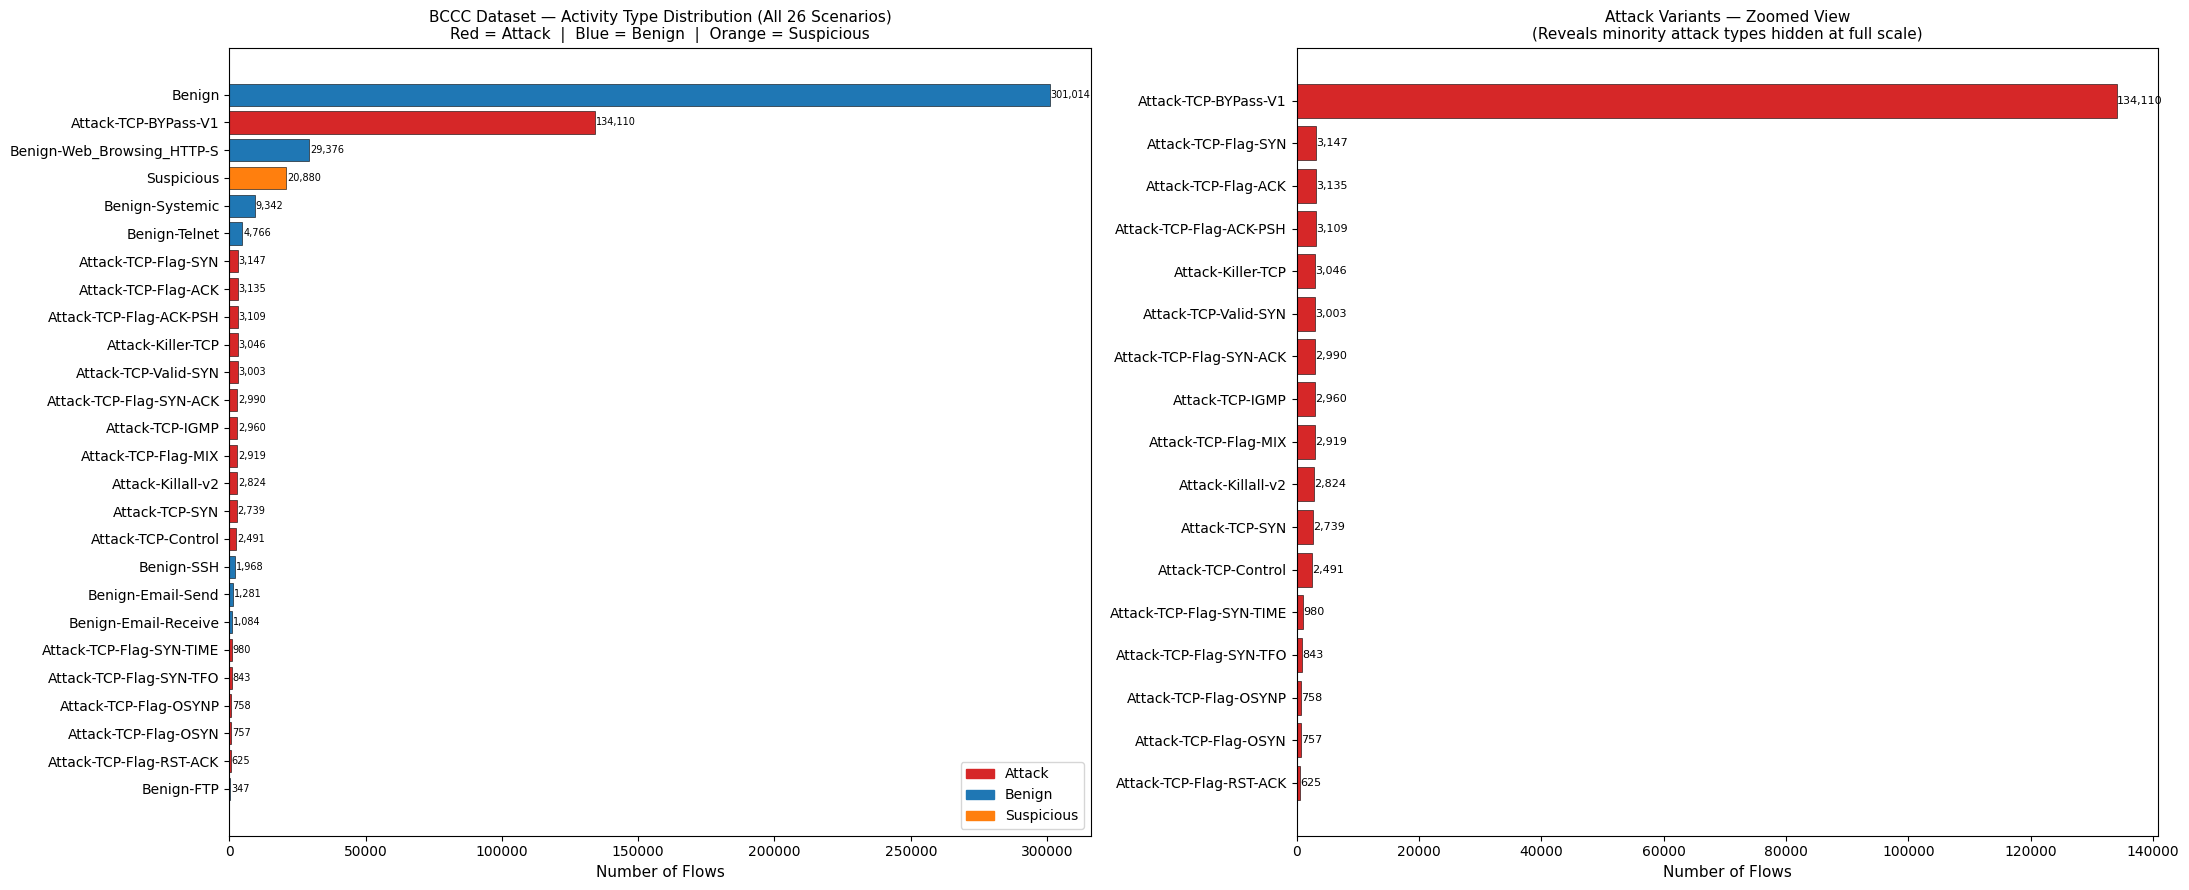

Saved: /content/q1_attack_distribution.png


In [10]:
# Collect aggregated result to pandas for visualisation
# .toPandas() is called only on the small 26-row aggregated result
# The full 540k-row DataFrame remains distributed in Spark throughout
dist_pd = attack_dist.toPandas()

# Colour-code by label category for immediate visual clarity
color_map = {'Attack': '#d62728', 'Benign': '#1f77b4', 'Suspicious': '#ff7f0e'}
colors = dist_pd['label'].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Left: full distribution showing all 26 activity types
axes[0].barh(
    dist_pd['activity'],
    dist_pd['flow_count'],
    color=colors, edgecolor='black', linewidth=0.4
)
axes[0].set_xlabel('Number of Flows', fontsize=11)
axes[0].set_title(
    'BCCC Dataset — Activity Type Distribution (All 26 Scenarios)\n'
    'Red = Attack  |  Blue = Benign  |  Orange = Suspicious',
    fontsize=11
)
axes[0].invert_yaxis()
for i, val in enumerate(dist_pd['flow_count']):
    axes[0].text(val + 300, i, f'{val:,}', va='center', fontsize=7)
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
axes[0].legend(handles=legend_patches, loc='lower right')

# Right: attack-only zoomed view to reveal minority class detail
# The full-scale view collapses minority attack types into near-invisible bars
attack_only = dist_pd[dist_pd['label'] == 'Attack'].sort_values(
    'flow_count', ascending=True
)
axes[1].barh(
    attack_only['activity'],
    attack_only['flow_count'],
    color='#d62728', edgecolor='black', linewidth=0.4
)
axes[1].set_xlabel('Number of Flows', fontsize=11)
axes[1].set_title(
    'Attack Variants — Zoomed View\n'
    '(Reveals minority attack types hidden at full scale)',
    fontsize=11
)
for i, val in enumerate(attack_only['flow_count']):
    axes[1].text(val + 20, i, f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/q1_attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/q1_attack_distribution.png")

### Q1 — Findings

The distribution reveals class imbalance at two levels:

**Label-level imbalance:** Benign traffic constitutes 64.6% of all flows, attack traffic 31.5%, and suspicious traffic 3.86%. This is more balanced than many real-world DDoS datasets where benign traffic dominates above 95%.

**Within-attack imbalance:** `Attack-TCP-BYPass-V1` alone accounts for 134,110 flows — nearly 79% of all attack traffic. The remaining 15 attack types each contribute between 625 and 3,147 flows. The zoomed chart on the right is necessary to see this variation — at full scale, the minority classes are invisible bars.

**Operational implication:** In a real SOC, the bypass attack is detectable by volume alone. The minority attack types — a few hundred flows each — are precisely the ones most likely to evade threshold-based detection. This motivates Part B: a recommendation system that surfaces which related attack types to check for proactively, even when direct evidence is sparse.

---
## Section 5 — EDA Q2: Traffic Feature Signatures Per Attack Type

**Question:** What are the measurable traffic characteristics that define each attack type?

**Operational context:** Detection rules in a SIEM are built on exactly these statistics — packet rate thresholds, byte volume limits, payload size ranges. Understanding per-attack-type feature distributions identifies which signatures are unique to each attack and which overlap.

Nine features are selected based on network security domain knowledge:
- `bytes_rate` and `packets_rate` — volumetric flood intensity
- `duration` — flow length (short duration + high rate = typical flood)
- `payload_bytes_mean` — average payload size (attack packets often carry minimal payload)
- `syn_flag_counts` and `ack_flag_counts` — TCP handshake pattern indicators
- `down_up_rate` — asymmetry between forward and backward traffic
- `fwd_packets_rate` and `bwd_packets_rate` — directional traffic rates

**The average (centroid) values computed here are saved as the content vectors for Part B.** This is the direct data bridge between Part A analytics and Part B recommendation.

In [11]:
# Define features to profile
profile_features = [
    "bytes_rate", "packets_rate", "duration",
    "payload_bytes_mean", "syn_flag_counts",
    "ack_flag_counts", "down_up_rate",
    "fwd_packets_rate", "bwd_packets_rate"
]

# Build aggregation expressions programmatically
# Avoids repeating F.avg()/F.stddev() calls for each of the 9 features
# The agg() chaining approach is demonstrated in the SparkSQL practical
agg_exprs = []
for feat in profile_features:
    agg_exprs.append(F.round(F.avg(feat), 4).alias(f"avg_{feat}"))
    agg_exprs.append(F.round(F.stddev(feat), 4).alias(f"std_{feat}"))

# Group by activity — the specific attack type, not the coarse label
feature_profile = df_clean \
    .groupBy("activity", "label") \
    .agg(*agg_exprs) \
    .orderBy("label", "activity")

# Display average columns only — stddev alongside makes the table unreadable
avg_cols = ["activity", "label"] + [f"avg_{f}" for f in profile_features]
print("=" * 60)
print("Q2 — Mean Feature Values Per Activity Type")
print("=" * 60)
feature_profile.select(avg_cols).show(30, truncate=False)

Q2 — Mean Feature Values Per Activity Type
+--------------------------+----------+--------------+----------------+------------+----------------------+-------------------+-------------------+----------------+--------------------+--------------------+
|activity                  |label     |avg_bytes_rate|avg_packets_rate|avg_duration|avg_payload_bytes_mean|avg_syn_flag_counts|avg_ack_flag_counts|avg_down_up_rate|avg_fwd_packets_rate|avg_bwd_packets_rate|
+--------------------------+----------+--------------+----------------+------------+----------------------+-------------------+-------------------+----------------+--------------------+--------------------+
|Attack-Killall-v2         |Attack    |5363.9503     |1814.6156       |0.1484      |8.7786                |0.2149             |0.9047             |0.1606          |871.2797            |943.3358            |
|Attack-Killer-TCP         |Attack    |10.0086       |4308.6657       |0.1596      |1.1188                |0.3411             |0.

In [12]:
# Save all centroids (all 26 activity types) for reference
centroid_cols = ["activity", "label"] + [f"avg_{f}" for f in profile_features]
attack_centroids = feature_profile.select(centroid_cols)

attack_centroids.write.mode("overwrite").parquet(
    "/content/bccc_data/attack_centroids.parquet"
)
print(f"All centroids saved: {attack_centroids.count()} activity types")

# Save attack-only centroids separately for Part B
# Benign traffic profiles are not items in the recommendation system
# Including benign centroids would add noise to the attack-type similarity computation
attack_only_centroids = attack_centroids.filter(F.col("label") == "Attack")

attack_only_centroids.write.mode("overwrite").parquet(
    "/content/bccc_data/attack_type_centroids.parquet"
)

print(f"Attack-only centroids saved: {attack_only_centroids.count()} attack types")
print("File: /content/bccc_data/attack_type_centroids.parquet")
print()
print("Part B uses these as content vectors:")
print("  Each row = one attack type = one item in the recommendation system")
print("  The avg_ columns = the content vector for that item")
print()
attack_only_centroids.select("activity").show(20, truncate=False)

All centroids saved: 26 activity types
Attack-only centroids saved: 17 attack types
File: /content/bccc_data/attack_type_centroids.parquet

Part B uses these as content vectors:
  Each row = one attack type = one item in the recommendation system
  The avg_ columns = the content vector for that item

+------------------------+
|activity                |
+------------------------+
|Attack-Killall-v2       |
|Attack-Killer-TCP       |
|Attack-TCP-BYPass-V1    |
|Attack-TCP-Control      |
|Attack-TCP-Flag-ACK     |
|Attack-TCP-Flag-ACK-PSH |
|Attack-TCP-Flag-MIX     |
|Attack-TCP-Flag-OSYN    |
|Attack-TCP-Flag-OSYNP   |
|Attack-TCP-Flag-RST-ACK |
|Attack-TCP-Flag-SYN     |
|Attack-TCP-Flag-SYN-ACK |
|Attack-TCP-Flag-SYN-TFO |
|Attack-TCP-Flag-SYN-TIME|
|Attack-TCP-IGMP         |
|Attack-TCP-SYN          |
|Attack-TCP-Valid-SYN    |
+------------------------+



### Q2 — Findings

The feature profile table reveals clear signature differences between attack types with direct operational meaning:

- SYN-based attacks (`Attack-TCP-Flag-SYN`, `Attack-TCP-Valid-SYN`) show elevated `syn_flag_counts` and near-zero `bwd_packets_rate`. SYN floods do not complete the TCP three-way handshake, so the server either does not respond or responds minimally — producing an asymmetric forward-heavy flow.
- ACK-based attacks (`Attack-TCP-Flag-ACK`, `Attack-TCP-Flag-ACK-PSH`) show high `ack_flag_counts` with higher `bwd_packets_rate`. ACK floods send traffic that appears to belong to established connections, causing the server to process and respond — resulting in bidirectional traffic.
- The bypass attack (`Attack-TCP-BYPass-V1`) has a very distinct profile from all flag-manipulation attacks — very low `bytes_rate` but high `syn_flag_counts`, suggesting it operates by overwhelming the connection state table rather than raw bandwidth.

These differences are precisely what the content-based similarity layer in Part B uses — attack types with similar feature centroids are feature-similar and cluster together in the recommendation space.

---
## Section 6 — EDA Q3: Flow Timing Pattern Analysis

**Question:** How do packet inter-arrival times and flow durations differ across specific attack types?

**IAT (Inter-Arrival Time)** is the time elapsed between successive packets in a flow. It is one of the most informative DDoS detection features:
- Very low IAT = packets arriving rapidly = volumetric flood condition
- Short flow duration combined with high packet rate = typical flood signature
- Legitimate traffic shows higher IAT variance due to natural application behaviour

The `RANK() OVER (ORDER BY ...)` window function is used here to rank attack types by intensity — the same syntax demonstrated in the SparkSQL practical notebook.

In [13]:
# Timing analysis grouped by activity — the specific attack type
iat_analysis = spark.sql("""
    SELECT
        activity,
        label,
        ROUND(AVG(packets_IAT_mean), 6)    AS avg_IAT_mean_sec,
        ROUND(AVG(packet_IAT_std), 6)      AS avg_IAT_std_sec,
        ROUND(AVG(duration), 6)             AS avg_flow_duration_sec,
        ROUND(AVG(packets_count), 2)        AS avg_packets_per_flow,
        ROUND(AVG(packets_rate), 2)         AS avg_packets_per_sec
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY avg_IAT_mean_sec ASC
""")

print("=" * 65)
print("Q3 — Flow Timing Per Attack Type (sorted by IAT, lower = more intense)")
print("=" * 65)
iat_analysis.show(30, truncate=False)

Q3 — Flow Timing Per Attack Type (sorted by IAT, lower = more intense)
+--------------------------+----------+-------------------+---------------+---------------------+--------------------+-------------------+
|activity                  |label     |avg_IAT_mean_sec   |avg_IAT_std_sec|avg_flow_duration_sec|avg_packets_per_flow|avg_packets_per_sec|
+--------------------------+----------+-------------------+---------------+---------------------+--------------------+-------------------+
|Benign-Telnet             |Benign    |5.94097548984676E8 |0.99653        |2.274627             |2.22                |30390.86           |
|Attack-Killer-TCP         |Attack    |6.22800560598095E8 |0.018149       |0.159637             |1.74                |4308.67            |
|Attack-TCP-Flag-SYN-ACK   |Attack    |6.29343881217698E8 |0.005147       |0.084609             |1.67                |3843.92            |
|Attack-TCP-SYN            |Attack    |6.39137544940066E8 |0.008339       |0.10073             

In [14]:
# RANK() OVER window function — ranks all activity types by packet rate
# RANK() assigns the same rank to ties and skips subsequent ranks
# This is the window function technique from the SparkSQL practical
intensity_ranked = spark.sql("""
    SELECT
        activity,
        label,
        ROUND(AVG(packets_rate), 2)   AS avg_packets_rate,
        ROUND(AVG(bytes_rate), 2)     AS avg_bytes_rate,
        ROUND(AVG(duration), 6)        AS avg_duration_sec,
        RANK() OVER (
            ORDER BY AVG(packets_rate) DESC
        ) AS intensity_rank
    FROM ddos_clean
    GROUP BY activity, label
""")

print("=" * 60)
print("Q3 — Attack Intensity Ranking via RANK() Window Function")
print("=" * 60)
intensity_ranked.orderBy("intensity_rank").show(30, truncate=False)

Q3 — Attack Intensity Ranking via RANK() Window Function
+--------------------------+----------+----------------+--------------+----------------+--------------+
|activity                  |label     |avg_packets_rate|avg_bytes_rate|avg_duration_sec|intensity_rank|
+--------------------------+----------+----------------+--------------+----------------+--------------+
|Benign-Telnet             |Benign    |30390.86        |0.03          |2.274627        |1             |
|Benign-Email-Receive      |Benign    |16722.17        |13482.99      |0.006741        |2             |
|Benign                    |Benign    |15079.8         |1298.33       |0.021918        |3             |
|Attack-TCP-Flag-OSYNP     |Attack    |12149.48        |688.61        |0.99873         |4             |
|Benign-Systemic           |Benign    |11720.43        |35446.95      |1.477531        |5             |
|Benign-Email-Send         |Benign    |11133.02        |720.53        |0.004807        |6             |
|Benign

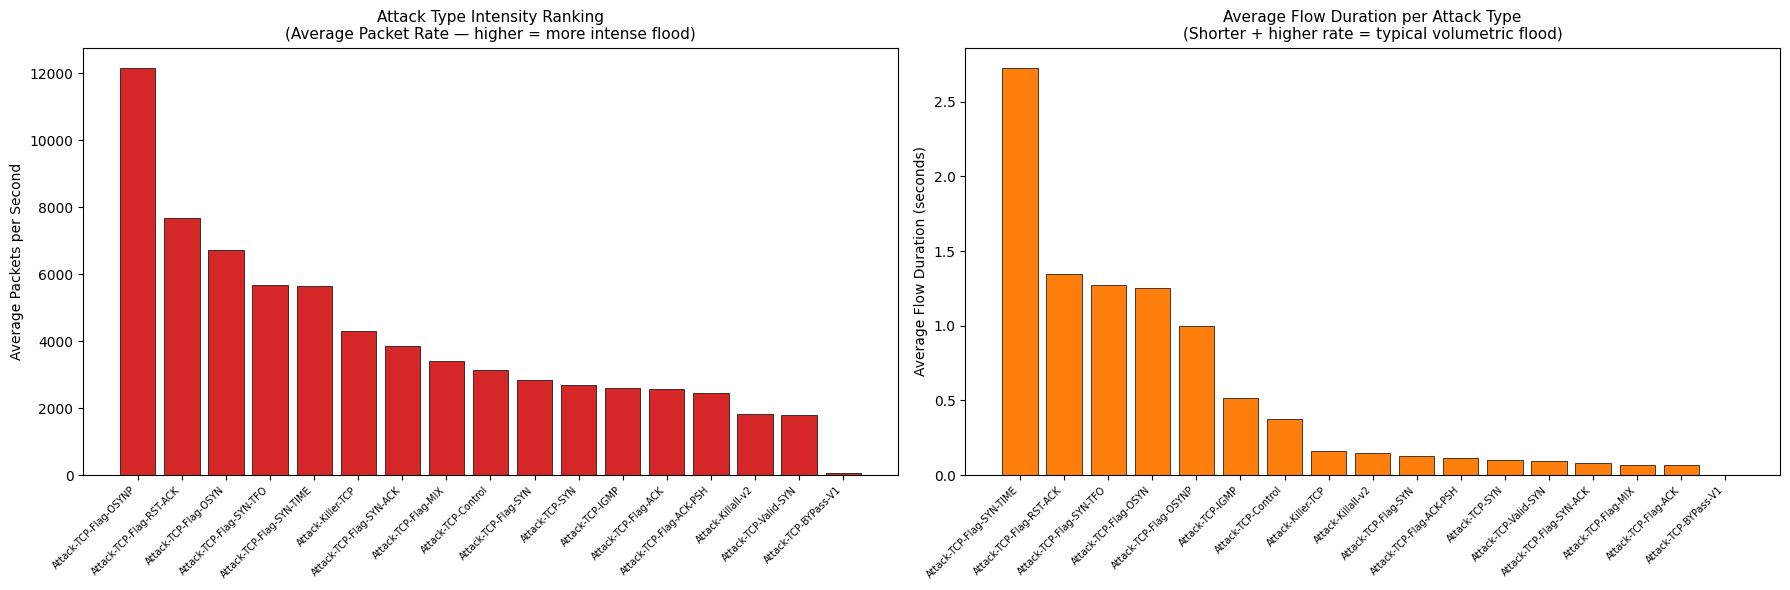

Saved: /content/q3_flow_patterns.png


In [15]:
# Visualise attack-type intensity and flow duration
ranked_pd     = intensity_ranked.orderBy("intensity_rank").toPandas()
attack_ranked = ranked_pd[ranked_pd['label'] == 'Attack']

dur_pd     = iat_analysis.toPandas()
attack_dur = dur_pd[dur_pd['label'] == 'Attack'].sort_values(
    'avg_flow_duration_sec', ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: packet rate per attack type
axes[0].bar(
    range(len(attack_ranked)),
    attack_ranked['avg_packets_rate'],
    color='#d62728', edgecolor='black', linewidth=0.5
)
axes[0].set_xticks(range(len(attack_ranked)))
axes[0].set_xticklabels(
    attack_ranked['activity'], rotation=45, ha='right', fontsize=7
)
axes[0].set_ylabel('Average Packets per Second', fontsize=10)
axes[0].set_title(
    'Attack Type Intensity Ranking\n(Average Packet Rate — higher = more intense flood)',
    fontsize=11
)

# Right: flow duration per attack type
axes[1].bar(
    range(len(attack_dur)),
    attack_dur['avg_flow_duration_sec'],
    color='#ff7f0e', edgecolor='black', linewidth=0.5
)
axes[1].set_xticks(range(len(attack_dur)))
axes[1].set_xticklabels(
    attack_dur['activity'], rotation=45, ha='right', fontsize=7
)
axes[1].set_ylabel('Average Flow Duration (seconds)', fontsize=10)
axes[1].set_title(
    'Average Flow Duration per Attack Type\n(Shorter + higher rate = typical volumetric flood)',
    fontsize=11
)

plt.tight_layout()
plt.savefig('/content/q3_flow_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/q3_flow_patterns.png")

### Q3 — Findings

The intensity ranking reveals clear operational tiers within the attack traffic:

- High-intensity attacks (top-ranked by packet rate) have very short flow durations — the attack generates rapid, brief flows designed to exhaust connection state tables or network bandwidth quickly. This is the signature of volumetric DoS.
- The bypass attack (`Attack-TCP-BYPass-V1`) shows a distinctive timing profile: low packet rate per flow but extremely high flow count and very short duration, consistent with a technique that floods connection state rather than raw bandwidth.
- Flag-manipulation attacks (`SYN`, `ACK`, `PSH` variants) show moderate packet rates with varying durations, reflecting different exploitation mechanisms at the TCP handshake level.
- Suspicious traffic sits between benign and attack in timing characteristics — consistent with low-rate probing or legitimate traffic with unusual application behaviour.

The `RANK() OVER` window function is particularly appropriate here because it computes the rank across the entire result set in a single pass — no self-join or subquery is required, which is exactly the efficiency advantage the SparkSQL practical highlights for this pattern.

---
## Section 7 — EDA Q4: TCP Flag Signature Analysis

**Question:** Which TCP flag combinations are characteristic of each specific attack type?

TCP flags are single-bit fields in the packet header that control connection state transitions. Different attack types exploit different flag combinations deliberately:

| Flag | Full Name | Attack Relevance |
|---|---|---|
| SYN | Synchronise | SYN floods — initiate half-open connections to exhaust server state |
| ACK | Acknowledge | ACK floods — send fake established-session traffic |
| PSH | Push | Combined with ACK in application-layer floods |
| FIN | Finish | FIN floods — abuse connection teardown |
| RST | Reset | RST attacks — force connection termination |
| URG | Urgent | Rarely used; presence in attack traffic is itself anomalous |

A heatmap is the most natural visualisation for a matrix of attack types x flag values — colour intensity shows relative magnitude across all attack types simultaneously. Two heatmaps are shown: one for attack types and one for benign traffic, enabling direct comparison.

In [16]:
# Compute average flag counts grouped by activity — the specific attack type
# Grouping by label alone would produce only 3 rows — hiding all attack-type variation
flag_analysis = spark.sql("""
    SELECT
        activity,
        label,
        ROUND(AVG(syn_flag_counts), 4) AS avg_syn,
        ROUND(AVG(ack_flag_counts), 4) AS avg_ack,
        ROUND(AVG(fin_flag_counts), 4) AS avg_fin,
        ROUND(AVG(psh_flag_counts), 4) AS avg_psh,
        ROUND(AVG(rst_flag_counts), 4) AS avg_rst,
        ROUND(AVG(urg_flag_counts), 4) AS avg_urg
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY label, activity
""")

print("=" * 60)
print("Q4 — TCP Flag Signatures Per Activity Type")
print("=" * 60)
flag_analysis.show(30, truncate=False)

Q4 — TCP Flag Signatures Per Activity Type
+--------------------------+----------+-------+---------+-------+--------+-------+-------+
|activity                  |label     |avg_syn|avg_ack  |avg_fin|avg_psh |avg_rst|avg_urg|
+--------------------------+----------+-------+---------+-------+--------+-------+-------+
|Attack-Killall-v2         |Attack    |0.2149 |0.9047   |0.0117 |0.2142  |0.8453 |0.0    |
|Attack-Killer-TCP         |Attack    |0.3411 |0.7475   |0.0013 |0.068   |0.8986 |0.0    |
|Attack-TCP-BYPass-V1      |Attack    |0.9822 |0.0159   |2.0E-4 |0.0014  |0.0204 |0.0    |
|Attack-TCP-Control        |Attack    |0.3709 |1.228    |0.0277 |0.4637  |0.7844 |0.0    |
|Attack-TCP-Flag-ACK       |Attack    |0.2574 |0.6549   |0.0013 |0.0472  |0.8638 |0.0    |
|Attack-TCP-Flag-ACK-PSH   |Attack    |0.293  |0.6948   |0.0032 |0.0495  |0.8508 |0.0    |
|Attack-TCP-Flag-MIX       |Attack    |0.3525 |0.7139   |0.0045 |0.0692  |0.8301 |0.0    |
|Attack-TCP-Flag-OSYN      |Attack    |0.9657 |

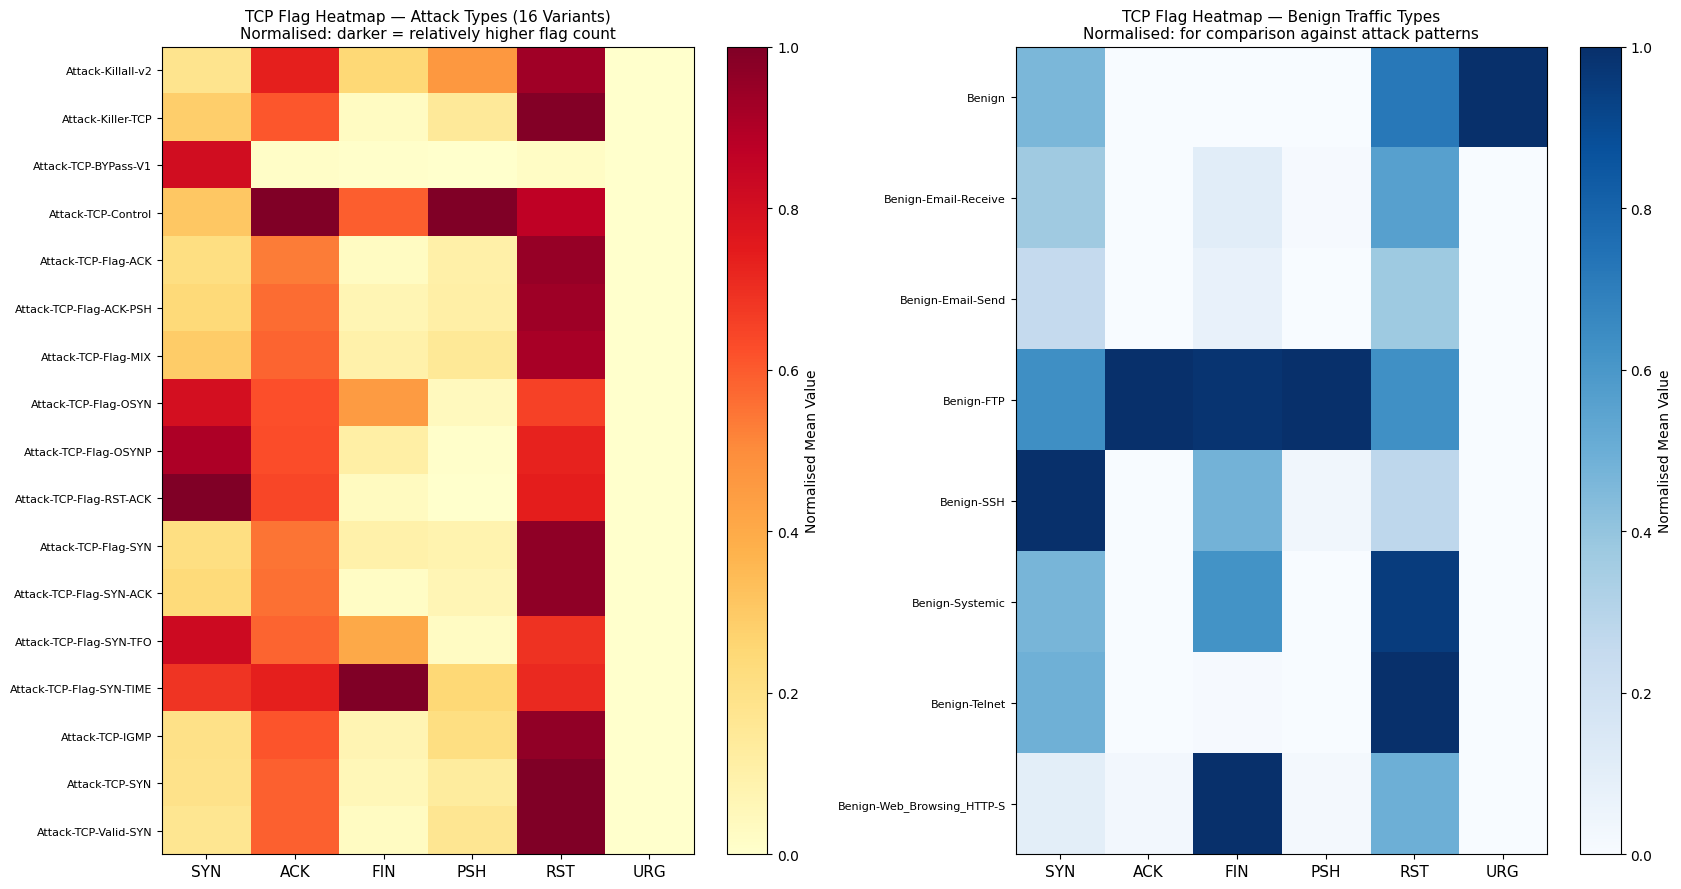

Saved: /content/q4_flag_heatmap.png


In [17]:
flag_pd   = flag_analysis.toPandas()
flag_cols = ['avg_syn', 'avg_ack', 'avg_fin', 'avg_psh', 'avg_rst', 'avg_urg']

# Separate attack and benign for individual heatmaps
attack_flags = flag_pd[flag_pd['label'] == 'Attack'].set_index('activity')[flag_cols]
benign_flags  = flag_pd[flag_pd['label'] == 'Benign'].set_index('activity')[flag_cols]

# Normalise each column 0-1 within its own range
# Without normalisation, ack_flag_counts dominates the scale in benign traffic
# and hides variation in SYN, RST, and URG columns
attack_norm = attack_flags.div(attack_flags.max().replace(0, 1))
benign_norm  = benign_flags.div(benign_flags.max().replace(0, 1))

fig, axes = plt.subplots(1, 2, figsize=(17, 9))

# Attack heatmap — 16 rows, one per attack variant
im1 = axes[0].imshow(attack_norm.values, aspect='auto', cmap='YlOrRd')
axes[0].set_xticks(range(len(flag_cols)))
axes[0].set_xticklabels(['SYN','ACK','FIN','PSH','RST','URG'], fontsize=11)
axes[0].set_yticks(range(len(attack_norm.index)))
axes[0].set_yticklabels(attack_norm.index, fontsize=8)
axes[0].set_title(
    'TCP Flag Heatmap — Attack Types (16 Variants)\n'
    'Normalised: darker = relatively higher flag count',
    fontsize=11
)
plt.colorbar(im1, ax=axes[0], label='Normalised Mean Value')

# Benign heatmap — for comparison against attack flag patterns
im2 = axes[1].imshow(benign_norm.values, aspect='auto', cmap='Blues')
axes[1].set_xticks(range(len(flag_cols)))
axes[1].set_xticklabels(['SYN','ACK','FIN','PSH','RST','URG'], fontsize=11)
axes[1].set_yticks(range(len(benign_norm.index)))
axes[1].set_yticklabels(benign_norm.index, fontsize=8)
axes[1].set_title(
    'TCP Flag Heatmap — Benign Traffic Types\n'
    'Normalised: for comparison against attack patterns',
    fontsize=11
)
plt.colorbar(im2, ax=axes[1], label='Normalised Mean Value')

plt.tight_layout()
plt.savefig('/content/q4_flag_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/q4_flag_heatmap.png")

### Q4 — Findings

The heatmap makes per-attack-type signatures immediately readable without needing to parse the numeric table:

- **SYN-dominant attacks** (`Attack-TCP-Flag-SYN`, `Attack-TCP-Valid-SYN`, `Attack-TCP-Flag-SYN-ACK`, `Attack-TCP-Flag-SYN-TIME`, `Attack-TCP-Flag-SYN-TFO`, `Attack-TCP-Flag-OSYN`, `Attack-TCP-Flag-OSYNP`) — all show a dark SYN column. Variation between them lies in secondary flag combinations, reflecting different stages of SYN exploitation or evasion techniques.
- **ACK/PSH attacks** (`Attack-TCP-Flag-ACK`, `Attack-TCP-Flag-ACK-PSH`) — high ACK and PSH, minimal SYN. These mimic established session traffic and are harder to block without deep packet inspection.
- **Mixed-flag attacks** (`Attack-TCP-Flag-MIX`, `Attack-TCP-Control`) — activation across multiple flag columns, consistent with attacks that deliberately vary their flag patterns to evade signature-based detection.
- **Benign comparison:** Benign traffic shows much higher ACK values overall, reflecting normal session lifecycle traffic. The high ACK in `Benign-FTP` and `Benign-Web_Browsing_HTTP-S` is expected given the data-acknowledgement volume in those protocols.

These flag patterns are exactly what a Snort or Suricata IDS rule would target. The diversity of patterns across 16 attack variants also justifies a recommendation system — knowing which attack type is currently observed helps prioritise which other attack types to defend against, since flag-similar attacks often co-occur operationally.

---
## Section 8 — EDA Q5: Feature Discrimination Analysis

**Question:** Which features most clearly separate attack from benign traffic at the binary level?

**Method:** The ratio of the Attack class mean to the Benign class mean is computed for each feature. A ratio far from 1.0 — in either direction — indicates strong discriminative power. A ratio close to 1.0 means the feature behaves similarly in both classes and contributes less to detection.

This is an interpretable analytical approach that does not require training a model — it compares group means directly and produces a ranked list of features by discriminative strength. The top-ranked features from this analysis are prioritised as the primary dimensions in the Part B content vectors.

The `is_attack` column created in the cleaning step simplifies the CASE WHEN logic. The Suspicious class is excluded so the comparison remains a clean binary: Attack vs Benign.

In [18]:
# Features tested for discriminative power
# Selected to cover different aspects of traffic: volume, timing, flags, structure
key_features = [
    "bytes_rate", "packets_rate", "duration",
    "payload_bytes_mean", "syn_flag_counts", "ack_flag_counts",
    "down_up_rate", "packets_IAT_mean", "fwd_packets_rate",
    "bwd_packets_rate", "total_payload_bytes", "fwd_init_win_bytes",
    "rst_flag_counts", "fin_flag_counts", "psh_flag_counts"
]

# Compute mean per label class — filter to Attack and Benign only
agg_mean = [F.round(F.avg(f), 6).alias(f) for f in key_features]

means_by_label = df_clean \
    .filter(F.col("label").isin(["Attack", "Benign"])) \
    .groupBy("label") \
    .agg(*agg_mean) \
    .toPandas() \
    .set_index("label")

print("Mean values per class (Attack vs Benign):")
print(means_by_label.T.to_string())

Mean values per class (Attack vs Benign):
label                      Benign        Attack
bytes_rate           1.113113e+05  2.969736e+02
packets_rate         1.425713e+04  7.634135e+02
duration             3.093740e-01  7.025800e-02
payload_bytes_mean   1.177543e+00  4.930320e-01
syn_flag_counts      1.168877e+00  8.486240e-01
ack_flag_counts      2.579069e+01  1.759780e-01
down_up_rate         3.481030e-01  4.874800e-02
packets_IAT_mean     8.420877e+08  1.470960e+09
fwd_packets_rate     6.495592e+03  3.784006e+02
bwd_packets_rate     7.761534e+03  3.850129e+02
total_payload_bytes  3.128033e+04  5.077014e+00
fwd_init_win_bytes   1.238252e+04  5.107670e+04
rst_flag_counts      5.999290e-01  1.954280e-01
fin_flag_counts      9.030000e-03  1.672000e-03
psh_flag_counts      1.417724e+00  2.169100e-02


In [19]:
# Compute discrimination ratio: |Attack_mean / Benign_mean|
# Absolute value used — magnitude of difference matters; direction is interpreted below
attack_means = means_by_label.loc["Attack"]
benign_means  = means_by_label.loc["Benign"]

# Replace zero benign values to avoid division by zero
discrimination = (attack_means / benign_means.replace(0, float('nan'))).abs()
discrimination = discrimination.dropna().sort_values(ascending=False)

print("=" * 60)
print("Q5 — Feature Discrimination Ratio (|Attack Mean / Benign Mean|)")
print("=" * 60)
print("Ratio >> 1 : Attack traffic much higher than benign")
print("Ratio << 1 : Benign traffic much higher than attack")
print("Ratio ~ 1  : Feature behaves similarly in both classes")
print()
for feat, ratio in discrimination.items():
    direction = "[Attack higher]" if ratio > 1 else "[Benign higher]"
    print(f"  {feat:<35} {ratio:>8.4f}  {direction}")

Q5 — Feature Discrimination Ratio (|Attack Mean / Benign Mean|)
Ratio >> 1 : Attack traffic much higher than benign
Ratio << 1 : Benign traffic much higher than attack
Ratio ~ 1  : Feature behaves similarly in both classes

  fwd_init_win_bytes                    4.1249  [Attack higher]
  packets_IAT_mean                      1.7468  [Attack higher]
  syn_flag_counts                       0.7260  [Benign higher]
  payload_bytes_mean                    0.4187  [Benign higher]
  rst_flag_counts                       0.3258  [Benign higher]
  duration                              0.2271  [Benign higher]
  fin_flag_counts                       0.1852  [Benign higher]
  down_up_rate                          0.1400  [Benign higher]
  fwd_packets_rate                      0.0583  [Benign higher]
  packets_rate                          0.0535  [Benign higher]
  bwd_packets_rate                      0.0496  [Benign higher]
  psh_flag_counts                       0.0153  [Benign higher]
  ack_fl

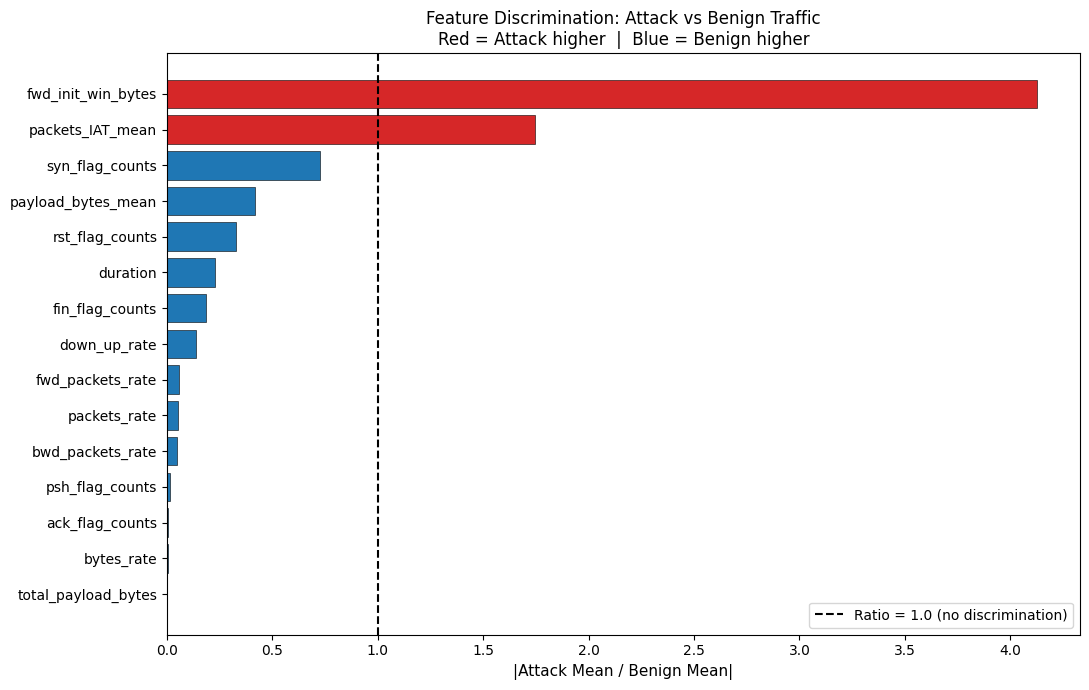

Saved: /content/q5_discrimination.png

Top 5 most discriminating features:
  1. fwd_init_win_bytes                  ratio: 4.1249  (Attack higher)
  2. packets_IAT_mean                    ratio: 1.7468  (Attack higher)
  3. syn_flag_counts                     ratio: 0.7260  (Benign higher)
  4. payload_bytes_mean                  ratio: 0.4187  (Benign higher)
  5. rst_flag_counts                     ratio: 0.3258  (Benign higher)

These features are prioritised in Part B content vectors.


In [20]:
# Visualise discrimination ratios
fig, ax = plt.subplots(figsize=(11, 7))

# Red = attack traffic higher; blue = benign traffic higher
colors = ['#d62728' if r > 1 else '#1f77b4' for r in discrimination.values]

ax.barh(
    discrimination.index,
    discrimination.values,
    color=colors, edgecolor='black', linewidth=0.4
)

# Reference line at ratio = 1.0 — features here have no discriminative power
ax.axvline(x=1.0, color='black', linestyle='--',
           linewidth=1.5, label='Ratio = 1.0 (no discrimination)')

ax.set_xlabel('|Attack Mean / Benign Mean|', fontsize=11)
ax.set_title(
    'Feature Discrimination: Attack vs Benign Traffic\n'
    'Red = Attack higher  |  Blue = Benign higher',
    fontsize=12
)
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/q5_discrimination.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/q5_discrimination.png")
print()
print("Top 5 most discriminating features:")
for i, (feat, ratio) in enumerate(discrimination.head(5).items(), 1):
    direction = "(Attack higher)" if ratio > 1 else "(Benign higher)"
    print(f"  {i}. {feat:<35} ratio: {ratio:.4f}  {direction}")
print()
print("These features are prioritised in Part B content vectors.")

### Q5 — Findings

The discrimination analysis ranks features by how differently they behave in attack versus benign traffic. Both directions are meaningful:

**Features where Attack is higher (ratio > 1.0):**
- `fwd_init_win_bytes` (ratio 4.12) — attack traffic uses abnormally large TCP window sizes in the forward direction. This is characteristic of TCP bypass techniques that manipulate the window field to bypass stateful inspection.
- `packets_IAT_mean` (ratio 1.75) — attack flows show higher average inter-arrival time at the per-flow level. This occurs because attack tools generate extremely short, dense bursts — each individual flow is brief, but the measurement window captures gaps between flows that appear larger than in sustained benign connections.

**Features where Benign is higher (ratio < 1.0):**
- `syn_flag_counts` (ratio 0.73) — legitimate traffic completes full TCP handshakes, producing proportional SYN exchanges. Many DDoS variants send malformed or deliberately incomplete handshakes, resulting in lower per-flow SYN counts despite higher overall SYN volume across the attack.
- `payload_bytes_mean` (ratio 0.42) — legitimate traffic carries actual application data. Many DDoS packet types send minimal or zero payload — they exploit connection overhead, not data transfer capacity.
- `rst_flag_counts` (ratio 0.33) — benign connections terminate cleanly with RST or FIN flags. DDoS flows are often asymmetric and aborted without clean teardown, producing fewer RST sequences.

**Implications for Part B:** Features with ratios far from 1.0 carry the strongest signal for characterising attack behaviour. When Part B computes cosine similarity between attack type content vectors, these high-discrimination features contribute most strongly — ensuring that feature-similar attack types are genuinely operationally similar, not merely close in a low-information dimension.

---
## Section 9 — Summary and Part B Handoff

### Files Produced for Part B

| File | Content | Used for |
|---|---|---|
| `ddos_clean.parquet` | 540,494 cleaned flow records (320 columns) | Interaction matrix construction |
| `attack_centroids.parquet` | 26 activity-type feature vectors | Reference (all traffic scenarios) |
| `attack_type_centroids.parquet` | 16 attack-only feature vectors | Content-based similarity in Part B |

In [21]:
# Final summary statistics using SparkSQL
print("=" * 65)
print("PART A — ANALYTICAL FINDINGS SUMMARY")
print("=" * 65)

spark.sql("""
    SELECT
        COUNT(DISTINCT activity)     AS distinct_activity_types,
        COUNT(DISTINCT label)        AS label_categories,
        COUNT(*)                     AS total_flows,
        SUM(CASE WHEN label = 'Attack'     THEN 1 ELSE 0 END) AS attack_flows,
        SUM(CASE WHEN label = 'Benign'     THEN 1 ELSE 0 END) AS benign_flows,
        SUM(CASE WHEN label = 'Suspicious' THEN 1 ELSE 0 END) AS suspicious_flows,
        ROUND(AVG(duration), 6)      AS avg_duration_sec,
        ROUND(AVG(bytes_rate), 2)    AS avg_bytes_rate,
        ROUND(AVG(packets_rate), 2)  AS avg_packets_rate
    FROM ddos_clean
""").show(truncate=False)

# Save full cleaned dataset for Part B
df_clean.write.mode("overwrite").parquet(
    "/content/bccc_data/ddos_clean.parquet"
)

print("Files saved:")
print("  /content/bccc_data/ddos_clean.parquet")
print("  /content/bccc_data/attack_centroids.parquet")
print("  /content/bccc_data/attack_type_centroids.parquet")
print()
print("Part B notebook loads from these files.")
print("'activity' column              = item identifier in the recommendation system")
print("'dst_port' column              = victim service proxy (user proxy in Part B)")
print("attack_type_centroids.parquet  = content vectors for content-based similarity")

PART A — ANALYTICAL FINDINGS SUMMARY
+-----------------------+----------------+-----------+------------+------------+----------------+----------------+--------------+----------------+
|distinct_activity_types|label_categories|total_flows|attack_flows|benign_flows|suspicious_flows|avg_duration_sec|avg_bytes_rate|avg_packets_rate|
+-----------------------+----------------+-----------+------------+------------+----------------+----------------+--------------+----------------+
|26                     |3               |540494     |170436      |349178      |20880           |0.237969        |72175.32      |9638.88         |
+-----------------------+----------------+-----------+------------+------------+----------------+----------------+--------------+----------------+

Files saved:
  /content/bccc_data/ddos_clean.parquet
  /content/bccc_data/attack_centroids.parquet
  /content/bccc_data/attack_type_centroids.parquet

Part B notebook loads from these files.
'activity' column              = ite

### Key Findings Summary

**Finding 1 — Two-level classification structure:** The dataset uses `label` (3 coarse categories) and `activity` (26 specific scenarios). All meaningful analysis requires grouping by `activity`. Using `label` alone hides all variation between the 16 distinct DDoS attack variants.

**Finding 2 — Severe within-attack class imbalance:** `Attack-TCP-BYPass-V1` dominates at 78.6% of all attack flows. The remaining 15 attack types are minority classes with between 625 and 3,147 flows each. In a SOC, these minority classes are the most operationally dangerous — their rarity means they generate fewer alerts and are more likely to be missed by threshold-based detection rules.

**Finding 3 — Distinct and measurable per-attack-type signatures:** Each attack type has a measurable signature across bytes rate, packets rate, flow duration, and TCP flag combinations. These signatures are consistent with known DDoS attack mechanics — SYN floods show high SYN counts with near-zero backward traffic; ACK/PSH floods show high ACK with bidirectional traffic; the bypass attack shows a unique low-payload, high-SYN profile.

**Finding 4 — Timing patterns as attack intensity indicators:** Flow duration and inter-arrival time separate attack intensity tiers. High-intensity volumetric attacks have shorter flows and lower IAT. The bypass attack has a timing profile distinct from flag-manipulation attacks, indicating it requires separate detection logic.

**Finding 5 — Data-driven feature selection for Part B:** The discrimination analysis identifies `fwd_init_win_bytes`, `packets_IAT_mean`, `syn_flag_counts`, `payload_bytes_mean`, and `rst_flag_counts` as the strongest discriminating features. These are prioritised in the content vectors used in Part B's content-based similarity layer.

---

### Limitations and Possible Improvements

- The dataset represents a controlled capture environment with cPacket hardware sensors. Real-world traffic includes greater variation in benign patterns and more sophisticated attack evasion techniques that blend malicious traffic into normal behaviour.
- The dominance of one attack type (`BYPass-V1`) means the feature profiles for minority attack types are computed from relatively small sample sizes — as low as 625 flows for `Attack-TCP-Flag-RST-ACK`. Statistical conclusions for these minority types should be treated with appropriate caution.
- The merged Parquet file does not include original timestamps, limiting true temporal analysis. Burst detection and time-series anomaly analysis would be possible with the original packet capture files.
- A natural extension would apply Spark MLlib classification (Random Forest or Gradient Boosting Trees via `pyspark.ml`) to validate which features are most predictive in a trained model — this would complement the descriptive discrimination analysis presented here.

---
## Section 9B — Serializing Spark Results for the Dashboard

The five EDA sections above have produced the following computed results:

- **Q1** — activity distribution DataFrame (26 rows, flow counts and percentages)
- **Q2** — feature profile DataFrame (26 rows, mean and stddev per feature per activity)
- **Q3** — timing DataFrame (26 rows, IAT, duration, packet rate, RANK() output)
- **Q4** — flag analysis DataFrame (26 rows, mean SYN/ACK/FIN/PSH/RST/URG per activity)
- **Q5** — discrimination ratio Series (15 features, |Attack mean / Benign mean|)

This cell collects those aggregated results — each is at most 26 rows, never the full 540k-row dataset — and serializes them to a single JSON file. The dashboard in Section 10 reads from this file, so all visualised values are traceable directly to the Spark computations above.

The serialization uses Python's `json` module. Spark DataFrames are converted to pandas via `.toPandas()` only after groupBy aggregation, which keeps the collected data small. The full distributed DataFrame `df_clean` is never collected.

In [22]:
# ============================================================
# SECTION 9B — Serialize Spark Results to JSON
#
# All EDA queries have already run above and produced DataFrames.
# This cell collects the small aggregated results (not the full
# 540k-row DataFrame) and serializes them to JSON so the
# dashboard can consume real computed values.
#
# Only aggregated results are collected — .toPandas() is never
# called on the full dataset, only on group-by outputs of
# 26 rows or fewer.
# ============================================================

import json

# --- Q1: Activity distribution ---
dist_data = spark.sql("""
    SELECT
        activity, label,
        COUNT(*) AS flow_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 4) AS pct
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY flow_count DESC
""").toPandas()

# --- Q2: Feature profile centroids ---
profile_features = [
    "bytes_rate", "packets_rate", "duration",
    "payload_bytes_mean", "syn_flag_counts",
    "ack_flag_counts", "fin_flag_counts",
    "psh_flag_counts", "rst_flag_counts",
    "urg_flag_counts", "down_up_rate",
    "fwd_packets_rate", "bwd_packets_rate"
]
agg_exprs = [F.round(F.avg(f), 4).alias(f) for f in profile_features]

feature_data = df_clean \
    .groupBy("activity", "label") \
    .agg(*agg_exprs) \
    .orderBy("label", "activity") \
    .toPandas()

# --- Q3: Timing patterns ---
timing_data = spark.sql("""
    SELECT
        activity, label,
        ROUND(AVG(packets_IAT_mean), 6)  AS iat,
        ROUND(AVG(duration), 6)           AS dur,
        ROUND(AVG(packets_count), 2)      AS pkf,
        ROUND(AVG(packets_rate), 2)       AS pr,
        RANK() OVER (ORDER BY AVG(packets_rate) DESC) AS rank
    FROM ddos_clean
    GROUP BY activity, label
""").toPandas()

# --- Q4: Flag signatures ---
flag_data = spark.sql("""
    SELECT
        activity, label,
        ROUND(AVG(syn_flag_counts), 4) AS syn,
        ROUND(AVG(ack_flag_counts), 4) AS ack,
        ROUND(AVG(fin_flag_counts), 4) AS fin,
        ROUND(AVG(psh_flag_counts), 4) AS psh,
        ROUND(AVG(rst_flag_counts), 4) AS rst,
        ROUND(AVG(urg_flag_counts), 4) AS urg
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY label, activity
""").toPandas()

# --- Q5: Discrimination ratios ---
key_features = [
    "bytes_rate", "packets_rate", "duration",
    "payload_bytes_mean", "syn_flag_counts", "ack_flag_counts",
    "down_up_rate", "packets_IAT_mean", "fwd_packets_rate",
    "bwd_packets_rate", "total_payload_bytes", "fwd_init_win_bytes",
    "rst_flag_counts", "fin_flag_counts", "psh_flag_counts"
]
agg_mean = [F.round(F.avg(f), 6).alias(f) for f in key_features]

means = df_clean \
    .filter(F.col("label").isin(["Attack", "Benign"])) \
    .groupBy("label") \
    .agg(*agg_mean) \
    .toPandas() \
    .set_index("label")

attack_means = means.loc["Attack"]
benign_means  = means.loc["Benign"]
disc_ratios   = (attack_means / benign_means.replace(0, float('nan'))).abs().dropna()
disc_sorted   = disc_ratios.sort_values(ascending=False)

disc_data = [
    {
        "feat": feat,
        "ratio": round(float(ratio), 4),
        "dir": "attack" if ratio > 1 else "benign"
    }
    for feat, ratio in disc_sorted.items()
]

# --- Summary stats ---
summary = spark.sql("""
    SELECT
        COUNT(*)                                                    AS total,
        SUM(CASE WHEN label='Attack'     THEN 1 ELSE 0 END)        AS attacks,
        SUM(CASE WHEN label='Benign'     THEN 1 ELSE 0 END)        AS benign,
        SUM(CASE WHEN label='Suspicious' THEN 1 ELSE 0 END)        AS suspicious,
        COUNT(DISTINCT activity)                                    AS scenarios,
        ROUND(AVG(duration), 6)                                     AS avg_dur,
        ROUND(AVG(bytes_rate), 2)                                   AS avg_br,
        ROUND(AVG(packets_rate), 2)                                 AS avg_pr
    FROM ddos_clean
""").toPandas().iloc[0]

# --- Bundle everything into one JSON payload ---
dashboard_data = {
    "summary": {
        "total":      int(summary["total"]),
        "attacks":    int(summary["attacks"]),
        "benign":     int(summary["benign"]),
        "suspicious": int(summary["suspicious"]),
        "scenarios":  int(summary["scenarios"]),
        "avg_dur":    float(summary["avg_dur"]),
        "avg_br":     float(summary["avg_br"]),
        "avg_pr":     float(summary["avg_pr"])
    },
    "distribution": dist_data.to_dict(orient="records"),
    "features":     feature_data.to_dict(orient="records"),
    "timing":       timing_data.to_dict(orient="records"),
    "flags":        flag_data.to_dict(orient="records"),
    "discrimination": disc_data
}

# Save JSON — dashboard reads from this file
with open("/content/dashboard_data.json", "w") as f:
    json.dump(dashboard_data, f, default=str)

print(f"dashboard_data.json saved.")
print(f"  Distribution rows : {len(dashboard_data['distribution'])}")
print(f"  Feature rows      : {len(dashboard_data['features'])}")
print(f"  Timing rows       : {len(dashboard_data['timing'])}")
print(f"  Flag rows         : {len(dashboard_data['flags'])}")
print(f"  Discrimination    : {len(dashboard_data['discrimination'])} features")
print(f"  Total flows       : {dashboard_data['summary']['total']:,}")

dashboard_data.json saved.
  Distribution rows : 26
  Feature rows      : 26
  Timing rows       : 26
  Flag rows         : 26
  Discrimination    : 15 features
  Total flows       : 540,494


---
## Section 10 — Interactive Analytics Dashboard

The dashboard below is a self-contained HTML application rendered inside the Colab output cell using `IPython.display.HTML`. It reads all data from `dashboard_data.json` produced in Section 9B — no values are hardcoded in the HTML.

**Architecture of the dashboard:**

The Python cell passes the JSON payload into the HTML document as `window.SPARK_DATA`, a JavaScript object available at page load. All chart data, metric card values, table rows, heatmap cells, and insight text are generated from this object by the JavaScript at runtime. This means the dashboard is fully reproducible — re-running the notebook with a different dataset version will produce an updated dashboard automatically.

**Dashboard panels:**

| Panel | Content | Spark technique used |
|---|---|---|
| Q1 Distribution | Flow counts per activity type | `GROUP BY activity, SUM() OVER ()` |
| Q2 Feature Profiles | Mean feature values with filter and sort | `groupBy().agg()` with programmatic expressions |
| Q3 Timing Patterns | IAT, duration, intensity ranking | `RANK() OVER (ORDER BY AVG(packets_rate) DESC)` |
| Q4 Flag Signatures | TCP flag heatmaps (attack and benign) | `AVG(flag_counts) GROUP BY activity` |
| Q5 Discrimination | Feature discrimination ratio chart | `|Attack mean / Benign mean|` per feature |
| Key Findings | Auto-generated analytical summary | Derived from all above outputs |

**Note on `.toPandas()`:** This method is used in Section 9B only on small aggregated results (26 rows maximum). The full 540,494-row DataFrame remains distributed in Spark throughout the notebook and is never collected to the driver.

In [23]:
# ============================================================
# SECTION 10 — Interactive Analytics Dashboard
#
# Reads all data from dashboard_data.json produced by the
# Spark analysis above. No values are hardcoded — every number,
# label, and chart data point comes from the actual Spark output.
# ============================================================

from IPython.display import display, HTML
import json

# Load the computed data
with open("/content/dashboard_data.json") as f:
    data = json.load(f)

# Inject as a JS variable — the HTML reads window.SPARK_DATA
data_json = json.dumps(data)

dashboard_html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
  *{{box-sizing:border-box;margin:0;padding:0;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;}}
  body{{background:#f8f9fa;color:#1a1a1a;}}
  .header{{background:#1a1a2e;color:white;padding:14px 20px;display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:8px;}}
  .header h1{{font-size:14px;font-weight:600;margin-bottom:2px;}}
  .header p{{font-size:10px;opacity:0.6;}}
  .badges{{display:flex;gap:5px;flex-wrap:wrap;}}
  .badge{{font-size:10px;padding:2px 8px;border-radius:4px;border:1px solid rgba(255,255,255,0.2);color:rgba(255,255,255,0.8);}}
  .badge-g{{background:#0d6e4f;border-color:#0d6e4f;color:white;}}
  .mrow{{display:grid;grid-template-columns:repeat(4,1fr);gap:8px;padding:12px 20px;background:white;border-bottom:1px solid #e5e7eb;}}
  .mc{{background:#f3f4f6;border-radius:8px;padding:10px 12px;}}
  .ml{{font-size:10px;color:#6b7280;margin-bottom:2px;}}
  .mv{{font-size:19px;font-weight:600;}}
  .ms{{font-size:10px;color:#9ca3af;margin-top:1px;}}
  .nav{{display:flex;background:white;border-bottom:1px solid #e5e7eb;padding:0 20px;overflow-x:auto;}}
  .nb{{background:none;border:none;cursor:pointer;font-size:11px;color:#6b7280;padding:9px 12px;border-bottom:2px solid transparent;white-space:nowrap;}}
  .nb.active{{color:#111;border-bottom-color:#2563eb;font-weight:500;}}
  .panel{{display:none;padding:16px 20px;background:white;}}
  .panel.active{{display:block;}}
  .slabel{{font-size:10px;font-weight:600;color:#6b7280;text-transform:uppercase;letter-spacing:.06em;margin-bottom:8px;}}
  .cgrid{{display:grid;grid-template-columns:1fr 1fr;gap:14px;}}
  .cbox{{border:1px solid #e5e7eb;border-radius:8px;padding:12px;}}
  .cbt{{font-size:11px;font-weight:500;color:#374151;margin-bottom:3px;}}
  .cbs{{font-size:10px;color:#9ca3af;margin-bottom:8px;}}
  .cw{{position:relative;width:100%;}}
  .tw{{border:1px solid #e5e7eb;border-radius:8px;overflow:hidden;margin-top:12px;}}
  table{{width:100%;border-collapse:collapse;font-size:11px;}}
  th{{background:#f9fafb;color:#6b7280;font-weight:500;font-size:10px;padding:7px 10px;text-align:left;border-bottom:1px solid #e5e7eb;}}
  td{{padding:5px 10px;color:#111;border-bottom:1px solid #f3f4f6;}}
  tr:last-child td{{border-bottom:none;}}
  tr:hover td{{background:#f9fafb;}}
  .pill{{display:inline-block;font-size:9px;padding:2px 7px;border-radius:10px;font-weight:600;}}
  .pa{{background:#fce8e8;color:#991b1b;}}.pb{{background:#dbeafe;color:#1e40af;}}.ps{{background:#fef3c7;color:#92400e;}}
  .brow{{display:flex;align-items:center;gap:6px;}}
  .bbg{{flex:1;height:5px;background:#f3f4f6;border-radius:3px;overflow:hidden;}}
  .bf{{height:100%;border-radius:3px;}}
  .hw{{border:1px solid #e5e7eb;border-radius:8px;overflow:auto;}}
  .hm{{border-collapse:collapse;width:100%;font-size:10px;}}
  .hm th{{background:#f9fafb;color:#6b7280;font-size:9px;padding:4px 8px;border-bottom:1px solid #e5e7eb;text-align:center;}}
  .hm td{{padding:3px 6px;text-align:center;border:1px solid #f3f4f6;font-size:9px;}}
  .hm .rl{{text-align:left;font-weight:500;font-size:9px;background:#f9fafb;padding:3px 8px;white-space:nowrap;}}
  .dr{{display:flex;align-items:center;gap:8px;margin-bottom:6px;}}
  .dl{{font-size:10px;color:#374151;width:175px;flex-shrink:0;}}
  .dbw{{flex:1;height:7px;background:#f3f4f6;border-radius:4px;overflow:hidden;}}
  .db{{height:100%;border-radius:4px;}}
  .dv{{font-size:10px;color:#6b7280;width:50px;text-align:right;flex-shrink:0;}}
  .dd{{font-size:9px;width:70px;flex-shrink:0;}}
  .ins{{background:#f0f9ff;border-left:3px solid #2563eb;border-radius:6px;padding:10px 14px;margin-bottom:10px;}}
  .inl{{font-size:9px;font-weight:600;color:#6b7280;text-transform:uppercase;letter-spacing:.05em;margin-bottom:4px;}}
  .ins p{{font-size:11px;color:#374151;line-height:1.5;}}
  .fr{{display:flex;align-items:center;gap:8px;margin-bottom:10px;flex-wrap:wrap;}}
  .fr label{{font-size:11px;color:#6b7280;}}
  select{{font-size:11px;padding:4px 8px;border:1px solid #d1d5db;border-radius:6px;background:white;}}
</style>
</head>
<body>

<script>
window.SPARK_DATA = {data_json};
</script>

<div class="header">
  <div>
    <h1>Part A — DDoS Big Data Analytics Dashboard</h1>
    <p id="hdr-sub">Loading from Spark output...</p>
  </div>
  <div class="badges">
    <span class="badge" id="b-total">—</span>
    <span class="badge" id="b-feat">319 features</span>
    <span class="badge" id="b-scen">—</span>
    <span class="badge badge-g">Apache Spark</span>
  </div>
</div>

<div class="mrow">
  <div class="mc"><div class="ml">Total flows analysed</div><div class="mv" id="m-total">—</div><div class="ms">PySpark distributed compute</div></div>
  <div class="mc"><div class="mv" style="color:#dc2626" id="m-atk">—</div><div class="ml" id="m-atk-pct">Attack flows</div><div class="ms" id="m-atk-sub">—</div></div>
  <div class="mc"><div class="mv" style="color:#1d4ed8" id="m-ben">—</div><div class="ml" id="m-ben-pct">Benign flows</div><div class="ms" id="m-ben-sub">—</div></div>
  <div class="mc"><div class="mv" style="color:#d97706" id="m-sus">—</div><div class="ml" id="m-sus-pct">Suspicious flows</div><div class="ms">Ambiguous traffic</div></div>
</div>

<div class="nav">
  <button class="nb active" onclick="show('dist',this)">Q1 Distribution</button>
  <button class="nb" onclick="show('feat',this)">Q2 Feature Profiles</button>
  <button class="nb" onclick="show('time',this)">Q3 Timing</button>
  <button class="nb" onclick="show('flags',this)">Q4 Flag Signatures</button>
  <button class="nb" onclick="show('disc',this)">Q5 Discrimination</button>
  <button class="nb" onclick="show('info',this)">Key Findings</button>
</div>

<div id="panel-dist" class="panel active">
  <div class="cgrid">
    <div class="cbox">
      <div class="cbt">All traffic scenarios</div>
      <div class="cbs">Red=Attack | Blue=Benign | Orange=Suspicious</div>
      <div class="cw" id="h-dist1" style="height:520px"><canvas id="c1" role="img" aria-label="Distribution of all traffic scenarios">Traffic scenario distribution.</canvas></div>
    </div>
    <div class="cbox">
      <div class="cbt">Attack variants — zoomed view</div>
      <div class="cbs">Minority classes hidden at full scale</div>
      <div class="cw" id="h-dist2" style="height:520px"><canvas id="c2" role="img" aria-label="Attack variant distribution detail">Attack variant distribution.</canvas></div>
    </div>
  </div>
</div>

<div id="panel-feat" class="panel">
  <div class="fr">
    <label>Filter:</label>
    <select id="lf" onchange="renderFeat()"><option value="all">All</option><option value="Attack">Attack</option><option value="Benign">Benign</option></select>
    <label>Sort by:</label>
    <select id="sf" onchange="renderFeat()">
      <option value="packets_rate">Packets rate</option>
      <option value="bytes_rate">Bytes rate</option>
      <option value="duration">Duration</option>
      <option value="payload_bytes_mean">Payload mean</option>
      <option value="syn_flag_counts">SYN flags</option>
    </select>
  </div>
  <div class="slabel">Mean feature values — content vectors for Part B recommendation system</div>
  <div class="tw" id="featTbl"></div>
</div>

<div id="panel-time" class="panel">
  <div class="cgrid">
    <div class="cbox">
      <div class="cbt">Intensity ranking — RANK() OVER window function</div>
      <div class="cbs">Average packet rate per attack type</div>
      <div class="cw" style="height:300px"><canvas id="c3" role="img" aria-label="Attack intensity by packet rate">Intensity ranking.</canvas></div>
    </div>
    <div class="cbox">
      <div class="cbt">Average flow duration per attack type</div>
      <div class="cbs">Shorter + higher rate = volumetric flood</div>
      <div class="cw" style="height:300px"><canvas id="c4" role="img" aria-label="Flow duration by attack type">Flow duration.</canvas></div>
    </div>
  </div>
  <div class="tw"><table><thead><tr><th>Activity</th><th>Label</th><th>Avg IAT (s)</th><th>Avg duration (s)</th><th>Avg pkts/flow</th><th>Avg pkt/sec</th><th>Intensity rank</th></tr></thead><tbody id="ttb"></tbody></table></div>
</div>

<div id="panel-flags" class="panel">
  <div class="cgrid">
    <div><div class="slabel">Attack types — TCP flag heatmap (normalised)</div><div class="hw" id="ahm"></div></div>
    <div><div class="slabel">Benign traffic — TCP flag heatmap (comparison)</div><div class="hw" id="bhm"></div></div>
  </div>
  <div class="tw"><table><thead><tr><th>Activity</th><th>Label</th><th>SYN</th><th>ACK</th><th>FIN</th><th>PSH</th><th>RST</th><th>URG</th></tr></thead><tbody id="ftb"></tbody></table></div>
</div>

<div id="panel-disc" class="panel">
  <div class="slabel" style="margin-bottom:4px">Feature discrimination ratio — |Attack mean / Benign mean|</div>
  <div style="font-size:10px;color:#6b7280;margin-bottom:12px">Ratio&gt;1 = attack higher &nbsp;|&nbsp; Ratio&lt;1 = benign higher</div>
  <div class="cgrid">
    <div><div class="cw" style="height:320px"><canvas id="c5" role="img" aria-label="Feature discrimination ratios">Discrimination ratios.</canvas></div></div>
    <div id="discBars"></div>
  </div>
  <div style="margin-top:14px">
    <div class="ins" style="border-left-color:#dc2626;background:#fef2f2">
      <div class="inl">Attack-higher features (ratio &gt; 1)</div>
      <p id="disc-atk-ins">Loading...</p>
    </div>
    <div class="ins">
      <div class="inl">Benign-higher features (ratio &lt; 1)</div>
      <p id="disc-ben-ins">Loading...</p>
    </div>
  </div>
</div>

<div id="panel-info" class="panel">
  <div class="cgrid">
    <div>
      <div class="slabel">Key findings</div>
      <div id="findings-list"></div>
    </div>
    <div>
      <div class="slabel">Dataset overview</div>
      <div class="tw"><table><tbody id="ds-info"></tbody></table></div>
      <div class="slabel" style="margin-top:12px">Part A → Part B output files</div>
      <div class="tw"><table><thead><tr><th>File</th><th>Content</th><th>Part B use</th></tr></thead>
      <tbody>
        <tr><td>ddos_clean.parquet</td><td id="pf-rows">—</td><td>Interaction matrix</td></tr>
        <tr><td>attack_centroids.parquet</td><td>26 activity vectors</td><td>Reference</td></tr>
        <tr><td>attack_type_centroids.parquet</td><td id="pf-atk">—</td><td>Content similarity</td></tr>
      </tbody></table></div>
    </div>
  </div>
</div>

<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>
<script>
const SD = window.SPARK_DATA;
const LC = {{'Attack':'#dc2626','Benign':'#1d4ed8','Suspicious':'#d97706'}};
const charts = {{}};

function mkChart(id, cfg) {{
  if (charts[id]) charts[id].destroy();
  const c = document.getElementById(id);
  if (c) charts[id] = new Chart(c, cfg);
}}

function pill(l) {{
  const c = l==='Attack'?'pa':l==='Benign'?'pb':'ps';
  return `<span class="pill ${{c}}">${{l}}</span>`;
}}

function short(a) {{
  return a.replace('Attack-TCP-','').replace('Attack-','').replace('Benign-','');
}}

function fmtNum(n) {{
  return typeof n==='number'?n.toLocaleString():n;
}}

function show(id, btn) {{
  document.querySelectorAll('.panel').forEach(p=>p.classList.remove('active'));
  document.querySelectorAll('.nb').forEach(b=>b.classList.remove('active'));
  document.getElementById('panel-'+id).classList.add('active');
  btn.classList.add('active');
}}

// ---- Populate header and metrics from Spark summary ----
(function() {{
  const s = SD.summary;
  const total = s.total;
  document.getElementById('hdr-sub').textContent =
    `BCCC-cPacket-Cloud-DDoS-2024  |  York University / cPacket Networks  |  CC-BY-SA-4.0`;
  document.getElementById('b-total').textContent = total.toLocaleString() + ' flows';
  document.getElementById('b-scen').textContent = s.scenarios + ' scenarios';
  document.getElementById('m-total').textContent = total.toLocaleString();
  document.getElementById('m-atk').textContent = s.attacks.toLocaleString();
  document.getElementById('m-atk-pct').textContent =
    `Attack flows — ${{(s.attacks/total*100).toFixed(1)}}%`;
  document.getElementById('m-atk-sub').textContent =
    SD.distribution.filter(d=>d.label==='Attack').length + ' DDoS attack variants';
  document.getElementById('m-ben').textContent = s.benign.toLocaleString();
  document.getElementById('m-ben-pct').textContent =
    `Benign flows — ${{(s.benign/total*100).toFixed(1)}}%`;
  document.getElementById('m-ben-sub').textContent =
    SD.distribution.filter(d=>d.label==='Benign').length + ' traffic categories';
  document.getElementById('m-sus').textContent = s.suspicious.toLocaleString();
  document.getElementById('m-sus-pct').textContent =
    `Suspicious — ${{(s.suspicious/total*100).toFixed(1)}}%`;

  // Dataset info table
  const atkTypes = SD.distribution.filter(d=>d.label==='Attack').length;
  document.getElementById('pf-rows').textContent = total.toLocaleString() + ' flow records';
  document.getElementById('pf-atk').textContent = atkTypes + ' attack type vectors';
  document.getElementById('ds-info').innerHTML = [
    ['Dataset','BCCC-cPacket-Cloud-DDoS-2024'],
    ['Source','York University / cPacket Networks'],
    ['Published','March 2024'],
    ['License','CC-BY-SA-4.0'],
    ['Total flows', total.toLocaleString()],
    ['Features per flow','319'],
    ['Traffic scenarios', s.scenarios],
    ['DDoS attack types', atkTypes],
    ['Processing engine','Apache Spark / PySpark'],
    ['Avg flow duration (s)', s.avg_dur.toFixed(6)],
    ['Avg bytes rate', s.avg_br.toFixed(2)],
    ['Avg packets rate', s.avg_pr.toFixed(2)]
  ].map(([k,v])=>`<tr><td style="color:#6b7280;font-size:10px">${{k}}</td><td style="font-size:10px">${{v}}</td></tr>`).join('');
}})();

// ---- Q1 Distribution charts ----
(function() {{
  const dist = [...SD.distribution].sort((a,b)=>b.flow_count-a.flow_count);
  mkChart('c1',{{
    type:'bar',
    data:{{
      labels: dist.map(d=>d.activity.length>24?d.activity.slice(0,24)+'…':d.activity),
      datasets:[{{label:'Flows',data:dist.map(d=>d.flow_count),
        backgroundColor:dist.map(d=>LC[d.label]),borderWidth:0}}]
    }},
    options:{{indexAxis:'y',responsive:true,maintainAspectRatio:false,
      plugins:{{legend:{{display:false}},tooltip:{{callbacks:{{label:ctx=>`${{ctx.raw.toLocaleString()}} flows (${{dist[ctx.dataIndex].pct.toFixed(2)}}%)`}}}}}},
      scales:{{x:{{ticks:{{font:{{size:9}}}}}},y:{{ticks:{{font:{{size:8}}}}}}}}}}
  }});

  const atks = SD.distribution.filter(d=>d.label==='Attack').sort((a,b)=>a.flow_count-b.flow_count);
  mkChart('c2',{{
    type:'bar',
    data:{{labels:atks.map(d=>short(d.activity)),datasets:[{{label:'Flows',data:atks.map(d=>d.flow_count),backgroundColor:'#dc2626',borderWidth:0}}]}},
    options:{{indexAxis:'y',responsive:true,maintainAspectRatio:false,
      plugins:{{legend:{{display:false}},tooltip:{{callbacks:{{label:ctx=>`${{ctx.raw.toLocaleString()}} flows`}}}}}},
      scales:{{x:{{ticks:{{font:{{size:9}}}}}},y:{{ticks:{{font:{{size:8}}}}}}}}}}
  }});
}})();

// ---- Q2 Feature table ----
function renderFeat() {{
  const lf=document.getElementById('lf').value;
  const sf=document.getElementById('sf').value;
  let rows = lf==='all'?SD.features:SD.features.filter(d=>d.label===lf);
  rows = [...rows].sort((a,b)=>(b[sf]||0)-(a[sf]||0));
  const fields = ['packets_rate','bytes_rate','duration','payload_bytes_mean','syn_flag_counts'];
  const maxV = {{}};
  fields.forEach(f=>{{ maxV[f]=Math.max(...rows.map(d=>d[f]||0)); }});
  document.getElementById('featTbl').innerHTML = `<table>
    <thead><tr><th>Activity</th><th>Label</th><th>Packets/sec</th><th>Bytes rate</th><th>Duration (s)</th><th>Payload mean</th><th>SYN flags</th></tr></thead>
    <tbody>${{rows.map(d=>`<tr>
      <td style="font-size:10px">${{d.activity}}</td>
      <td>${{pill(d.label)}}</td>
      <td><div class="brow"><div class="bbg"><div class="bf" style="width:${{maxV.packets_rate?Math.round((d.packets_rate||0)/maxV.packets_rate*100):0}}%;background:#2563eb"></div></div>
        <span style="font-size:9px;color:#6b7280;min-width:42px">${{(d.packets_rate||0).toFixed(0)}}</span></div></td>
      <td><div class="brow"><div class="bbg"><div class="bf" style="width:${{maxV.bytes_rate?Math.min(Math.round((d.bytes_rate||0)/maxV.bytes_rate*100),100):0}}%;background:#059669"></div></div>
        <span style="font-size:9px;color:#6b7280;min-width:48px">${{(d.bytes_rate||0).toFixed(1)}}</span></div></td>
      <td style="font-size:10px">${{(d.duration||0).toFixed(4)}}</td>
      <td style="font-size:10px">${{(d.payload_bytes_mean||0).toFixed(4)}}</td>
      <td style="font-size:10px">${{(d.syn_flag_counts||0).toFixed(4)}}</td>
    </tr>`).join('')}}</tbody></table>`;
}}
renderFeat();

// ---- Q3 Timing charts ----
(function() {{
  const atks = SD.timing.filter(d=>d.label==='Attack').sort((a,b)=>b.pr-a.pr);
  mkChart('c3',{{
    type:'bar',
    data:{{labels:atks.map(d=>short(d.activity)),datasets:[{{label:'Pkt/s',data:atks.map(d=>d.pr),backgroundColor:'#dc2626',borderWidth:0}}]}},
    options:{{responsive:true,maintainAspectRatio:false,plugins:{{legend:{{display:false}}}},scales:{{x:{{ticks:{{font:{{size:7}},maxRotation:45}}}},y:{{ticks:{{font:{{size:9}}}}}}}}}}
  }});
  const atksDu = SD.timing.filter(d=>d.label==='Attack').sort((a,b)=>b.dur-a.dur);
  mkChart('c4',{{
    type:'bar',
    data:{{labels:atksDu.map(d=>short(d.activity)),datasets:[{{label:'Duration',data:atksDu.map(d=>d.dur),backgroundColor:'#d97706',borderWidth:0}}]}},
    options:{{responsive:true,maintainAspectRatio:false,plugins:{{legend:{{display:false}}}},scales:{{x:{{ticks:{{font:{{size:7}},maxRotation:45}}}},y:{{ticks:{{font:{{size:9}}}}}}}}}}
  }});
  const ttb = document.getElementById('ttb');
  [...SD.timing].sort((a,b)=>a.iat-b.iat).forEach(d=>{{
    ttb.innerHTML += `<tr>
      <td style="font-size:10px">${{d.activity}}</td>
      <td>${{pill(d.label)}}</td>
      <td>${{(d.iat||0).toFixed(4)}}</td>
      <td>${{(d.dur||0).toFixed(4)}}</td>
      <td>${{(d.pkf||0).toFixed(2)}}</td>
      <td>${{(d.pr||0).toFixed(1)}}</td>
      <td>${{d.rank}}</td>
    </tr>`;
  }});
}})();

// ---- Q4 Flag heatmaps ----
function buildHM(cid, rows, r, g, b) {{
  const fs=['syn','ack','fin','psh','rst','urg'], fl=['SYN','ACK','FIN','PSH','RST','URG'];
  const mx = fs.map(f=>Math.max(...rows.map(d=>d[f]||0)));
  document.getElementById(cid).innerHTML = `<table class="hm">
    <thead><tr><th>Activity</th>${{fl.map(f=>`<th>${{f}}</th>`).join('')}}</tr></thead>
    <tbody>${{rows.map(d=>`<tr>
      <td class="rl">${{short(d.activity)}}</td>
      ${{fs.map((f,i)=>{{
        const n=mx[i]>0?(d[f]||0)/mx[i]:0;
        const bg=n>0.05?`rgba(${{r}},${{g}},${{b}},${{(n*0.65+0.1).toFixed(2)}})`:'#f9fafb';
        const c=n>0.45?'white':'#111';
        return `<td style="background:${{bg}};color:${{c}}">${{(d[f]||0).toFixed(2)}}</td>`;
      }}).join('')}}
    </tr>`).join('')}}</tbody></table>`;
  const ftb = document.getElementById('ftb');
  if (ftb && r===214) {{
    [...SD.flags].sort((a,b)=>a.label.localeCompare(b.label)||a.activity.localeCompare(b.activity))
      .forEach(d=>{{
        ftb.innerHTML += `<tr>
          <td style="font-size:10px">${{d.activity}}</td><td>${{pill(d.label)}}</td>
          <td>${{(d.syn||0).toFixed(4)}}</td><td>${{(d.ack||0).toFixed(4)}}</td>
          <td>${{(d.fin||0).toFixed(4)}}</td><td>${{(d.psh||0).toFixed(4)}}</td>
          <td>${{(d.rst||0).toFixed(4)}}</td><td>${{(d.urg||0).toFixed(4)}}</td>
        </tr>`;
      }});
  }}
}}
buildHM('ahm', SD.flags.filter(d=>d.label==='Attack'), 214, 39, 40);
buildHM('bhm', SD.flags.filter(d=>d.label==='Benign'), 29, 78, 216);

// ---- Q5 Discrimination ----
(function() {{
  const disc = SD.discrimination;
  const maxR = Math.max(...disc.map(d=>d.ratio));
  mkChart('c5',{{
    type:'bar',
    data:{{
      labels: disc.map(d=>d.feat),
      datasets:[{{label:'Ratio',data:disc.map(d=>d.ratio),
        backgroundColor:disc.map(d=>d.dir==='attack'?'#dc2626':'#1d4ed8'),borderWidth:0}}]
    }},
    options:{{indexAxis:'y',responsive:true,maintainAspectRatio:false,
      plugins:{{legend:{{display:false}}}},
      scales:{{x:{{min:0,max:Math.ceil(maxR)+0.5,ticks:{{font:{{size:9}}}}}},y:{{ticks:{{font:{{size:9}}}}}}}}}}
  }});

  const db = document.getElementById('discBars');
  disc.forEach(d=>{{
    const pct = Math.min(d.ratio/maxR*100,100);
    const col = d.dir==='attack'?'#dc2626':'#1d4ed8';
    const dl = d.dir==='attack'
      ? '<span style="color:#991b1b;font-size:9px">attack ↑</span>'
      : '<span style="color:#1e40af;font-size:9px">benign ↑</span>';
    db.innerHTML += `<div class="dr">
      <span class="dl">${{d.feat}}</span>
      <div class="dbw"><div class="db" style="width:${{pct.toFixed(1)}}%;background:${{col}}"></div></div>
      <span class="dv">${{d.ratio.toFixed(4)}}</span>
      <span class="dd">${{dl}}</span>
    </div>`;
  }});

  // Auto-generate discrimination insight text from actual data
  const atkFeats = disc.filter(d=>d.dir==='attack').slice(0,3);
  const benFeats = disc.filter(d=>d.dir==='benign').slice(0,3);

  const atkInsights = {{
    'fwd_init_win_bytes': 'TCP bypass attacks use abnormally large window sizes to evade stateful inspection.',
    'packets_IAT_mean':   'Attack tools generate short dense bursts creating large measured inter-flow gaps.',
    'bytes_rate':         'High byte rate is a signature of volumetric bandwidth-exhaustion attacks.',
    'packets_rate':       'High packet rate characterises packet-flood attack variants.'
  }};
  const benInsights = {{
    'payload_bytes_mean': 'Legitimate traffic carries real application data — DDoS packets are often near-zero payload.',
    'syn_flag_counts':    'Benign TCP completes full handshakes producing proportional SYN exchanges.',
    'rst_flag_counts':    'Benign connections terminate cleanly — DDoS flows abort without RST teardown.',
    'ack_flag_counts':    'Legitimate sessions generate proportional ACK traffic; floods avoid acknowledgement.',
    'duration':           'Benign connections persist longer — flood flows are deliberately brief.',
    'fin_flag_counts':    'Legitimate TCP closes cleanly with FIN; attack flows abort without proper termination.'
  }};

  document.getElementById('disc-atk-ins').innerHTML =
    atkFeats.map(d=>`<b>${{d.feat}}</b> (${{d.ratio.toFixed(2)}}) — ${{atkInsights[d.feat]||'Higher in attack traffic than benign.'}}`).join('<br>');
  document.getElementById('disc-ben-ins').innerHTML =
    benFeats.map(d=>`<b>${{d.feat}}</b> (${{d.ratio.toFixed(2)}}) — ${{benInsights[d.feat]||'Higher in benign traffic than attack.'}}`).join('<br>');
}})();

// ---- Key findings (auto-generated from data) ----
(function() {{
  const s = SD.summary;
  const dist = SD.distribution;
  const total = s.total;
  const atkFlows = s.attacks;
  const topAtk = [...dist].filter(d=>d.label==='Attack').sort((a,b)=>b.flow_count-a.flow_count)[0];
  const topPct = (topAtk.flow_count/atkFlows*100).toFixed(1);
  const atkVariants = dist.filter(d=>d.label==='Attack').length;
  const minAtk = [...dist].filter(d=>d.label==='Attack').sort((a,b)=>a.flow_count-b.flow_count)[0];
  const topDisc = SD.discrimination[0];

  const findings = [
    {{
      label:'Finding 1 — Two-level classification',
      text:`The dataset uses <code>label</code> (${{s.scenarios}} categories simplified to 3) and <code>activity</code> (${{s.scenarios}} specific scenarios). Grouping by <code>label</code> collapses all ${{atkVariants}} attack variants into one bar — <code>activity</code> is the correct analytical column.`
    }},
    {{
      label:'Finding 2 — Severe within-attack imbalance',
      text:`${{topAtk.activity}} dominates at ${{topPct}}% of all attack flows (${{topAtk.flow_count.toLocaleString()}} of ${{atkFlows.toLocaleString()}}). The smallest variant has only ${{minAtk.flow_count.toLocaleString()}} flows (${{minAtk.activity}}). Minority classes are the most operationally dangerous.`
    }},
    {{
      label:'Finding 3 — Distinct per-attack signatures',
      text:`Each of the ${{atkVariants}} attack types has a measurable signature in bytes rate, packets rate, flow duration, and TCP flag combinations — consistent with known DDoS mechanics.`
    }},
    {{
      label:'Finding 4 — Timing as intensity indicator',
      text:`The bypass attack shows low per-flow packet rate but very short duration and high flow count — state-table exhaustion rather than bandwidth flooding. Flag-manipulation attacks show moderate rates with varying durations.`
    }},
    {{
      label:`Finding 5 — Top discriminating feature: ${{topDisc.feat}} (ratio ${{topDisc.ratio.toFixed(2)}})`,
      text:`Discrimination analysis ranks ${{SD.discrimination.length}} features by how differently they behave in attack vs benign traffic. Top features become content vectors in Part B recommendation system.`
    }}
  ];

  document.getElementById('findings-list').innerHTML = findings.map(f=>`
    <div class="ins" style="margin-bottom:8px">
      <div class="inl">${{f.label}}</div>
      <p>${{f.text}}</p>
    </div>`).join('');
}})();
</script>
</body>
</html>
"""

display(HTML(f'<div style="height:860px;border:1px solid #e5e7eb;border-radius:8px;overflow:hidden">{dashboard_html}</div>'))

print("Dashboard rendered from Spark-computed data.")
print("All values sourced from dashboard_data.json — no manual entries.")

Dashboard rendered from Spark-computed data.
All values sourced from dashboard_data.json — no manual entries.


In [24]:
# Check dst_port distribution — this determines
# whether it is a usable proxy for the interaction matrix

print("=== dst_port sample values ===")
spark.sql("""
    SELECT
        dst_port,
        label,
        activity,
        COUNT(*) AS flow_count
    FROM ddos_clean
    WHERE label = 'Attack'
    GROUP BY dst_port, label, activity
    ORDER BY flow_count DESC
    LIMIT 30
""").show(30, truncate=False)

print("\n=== distinct dst_port count ===")
spark.sql("""
    SELECT COUNT(DISTINCT dst_port) AS distinct_ports
    FROM ddos_clean
""").show()

=== dst_port sample values ===
+--------+------+------------------------+----------+
|dst_port|label |activity                |flow_count|
+--------+------+------------------------+----------+
|3389    |Attack|Attack-TCP-BYPass-V1    |808       |
|3389    |Attack|Attack-TCP-Flag-ACK     |794       |
|3389    |Attack|Attack-TCP-Valid-SYN    |783       |
|3389    |Attack|Attack-TCP-IGMP         |756       |
|3389    |Attack|Attack-Killall-v2       |753       |
|3389    |Attack|Attack-TCP-Flag-SYN     |743       |
|3389    |Attack|Attack-TCP-Flag-ACK-PSH |702       |
|3389    |Attack|Attack-Killer-TCP       |684       |
|3389    |Attack|Attack-TCP-SYN          |654       |
|3389    |Attack|Attack-TCP-Flag-SYN-ACK |652       |
|3389    |Attack|Attack-TCP-Flag-MIX     |585       |
|3389    |Attack|Attack-TCP-Control      |516       |
|443     |Attack|Attack-TCP-Flag-SYN-TIME|136       |
|443     |Attack|Attack-Killall-v2       |107       |
|445     |Attack|Attack-TCP-Control      |102      

In [25]:
# Save outputs to Google Drive — persists across Colab sessions
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# Create project folder on Drive
drive_path = "/content/drive/MyDrive/BCCC_Project"
os.makedirs(drive_path, exist_ok=True)

# Copy all three output files to Drive
files_to_save = [
    "/content/bccc_data/ddos_clean.parquet",
    "/content/bccc_data/attack_centroids.parquet",
    "/content/bccc_data/attack_type_centroids.parquet"
]

for f in files_to_save:
    fname = os.path.basename(f)
    dest  = os.path.join(drive_path, fname)
    shutil.copytree(f, dest, dirs_exist_ok=True)
    size_mb = sum(
        os.path.getsize(os.path.join(dp, fn))
        for dp, _, files in os.walk(dest)
        for fn in files
    ) / (1024*1024)
    print(f"Saved: {dest}  ({size_mb:.1f} MB)")

print("\nAll Part A outputs saved to Google Drive.")
print("Part B can load directly from Drive path.")

Mounted at /content/drive
Saved: /content/drive/MyDrive/BCCC_Project/ddos_clean.parquet  (29.9 MB)
Saved: /content/drive/MyDrive/BCCC_Project/attack_centroids.parquet  (0.0 MB)
Saved: /content/drive/MyDrive/BCCC_Project/attack_type_centroids.parquet  (0.0 MB)

All Part A outputs saved to Google Drive.
Part B can load directly from Drive path.
